In [ ]:
# LIMPIEZA

import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')
ruta = "/content/drive/MyDrive/DataXperience Proyecto/telco_data.csv"
df = pd.read_csv(ruta)

print("Dimensiones:", df.shape)
df.head()

Mounted at /content/drive
Dimensiones: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("=" * 60)
print("1) DIMENSIONES")
print("=" * 60)
print(f"   {df.shape[0]} filas x {df.shape[1]} columnas")

print("\n" + "=" * 60)
print("2) TIPOS Y DATOS PRESENTES")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("3) FALTANTES POR COLUMNA")
print("=" * 60)
print(df.isna().sum())

print("\n" + "=" * 60)
print("4) FILAS COMPLETAMENTE DUPLICADAS")
print("=" * 60)
print(f"   {df.duplicated().sum()} filas repetidas")
print(f"   {df.duplicated(subset=['customerID']).sum()} customerID repetidos")

print("=" * 60)
print("5) ESTADISTICOS DE LAS COLUMNAS NUMERICAS")
print("=" * 60)
print(df.describe())

print("\n" + "=" * 60)
print("6) VALORES UNICOS DE LAS COLUMNAS DE TEXTO")
print("=" * 60)
columnas_texto = df.select_dtypes(include="object").columns.drop("customerID")
for col in columnas_texto:
    print(f"\n--- {col}: {df[col].nunique()} valores distintos ---")
    print(df[col].value_counts(dropna=False))

1) DIMENSIONES
   7043 filas x 21 columnas

2) TIPOS Y DATOS PRESENTES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   6043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       5543 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          

In [ ]:
df_limpio = df.copy()   # a partir de aqui  todo se escribe sobre df_limpio osea la copia

print("Antes:", list(df_limpio.columns))

# Minuscula y sin espacios sobrantes.
# Los nombres originales vienen en CamelCase pegado
# Asi que basta con pasar todo a minuscula
df_limpio.columns = (
    df_limpio.columns
    .str.strip()
    .str.lower()
)

print("Despues:", list(df_limpio.columns))

Antes: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Despues: ['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


In [ ]:
antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates(subset=["customerid"])
print(f"Filas antes: {antes}  ->  despues: {len(df_limpio)}  (se eliminaron {antes - len(df_limpio)})")
# No se elimino nada cada customerid aparece una sola vez.

Filas antes: 7043  ->  despues: 7043  (se eliminaron 0)


In [ ]:
columnas_texto = df_limpio.select_dtypes(include="object").columns.drop("customerid")

cambios = 0
for col in columnas_texto:
    original = df_limpio[col].copy()
    df_limpio[col] = df_limpio[col].str.strip()
    cambios += (original != df_limpio[col]).sum()

print(f"Celdas de texto con espacios sobrantes que se corrigieron: {cambios}")
print("\nConfirmando que las categorias ya son consistentes, ej. 'contract':")
print(df_limpio["contract"].unique())

Celdas de texto con espacios sobrantes que se corrigieron: 4261

Confirmando que las categorias ya son consistentes, ej. 'contract':
['Month-to-month' 'One year' 'Two year']


In [ ]:
revisar_tc = pd.to_numeric(df_limpio["totalcharges"], errors="coerce")
filas_problema = df_limpio.loc[revisar_tc.isna(), ["customerid", "tenure", "monthlycharges", "totalcharges"]]

print(f"Filas donde 'totalcharges' NO es un numero valido: {len(filas_problema)}")
filas_problema

Filas donde 'totalcharges' NO es un numero valido: 11


,customerid,tenure,monthlycharges,totalcharges
488,4472-LVYGI,0.0,52.55,
753,3115-CZMZD,0.0,20.25,
936,5709-LVOEQ,0.0,80.85,
1082,4367-NUYAO,0.0,25.75,
1340,1371-DWPAZ,NaN,56.05,
3331,7644-OMVMY,0.0,19.85,
3826,3213-VVOLG,0.0,25.35,
4380,2520-SGTTA,0.0,20.00,
5218,2923-ARZLG,0.0,19.70,
6670,4075-WKNIU,NaN,NaN,


In [ ]:
df_limpio["totalcharges"] = pd.to_numeric(df_limpio["totalcharges"], errors="coerce")
print("Tipo de dato ahora:", df_limpio["totalcharges"].dtype)
print("Faltantes en totalcharges:", df_limpio["totalcharges"].isna().sum())

Tipo de dato ahora: float64
Faltantes en totalcharges: 11


In [ ]:
print("tenure fuera de [0, 72]:", ((df_limpio["tenure"] < 0) | (df_limpio["tenure"] > 72)).sum())
print("monthlycharges negativo   :", (df_limpio["monthlycharges"] < 0).sum())
print("totalcharges negativo     :", (df_limpio["totalcharges"] < 0).sum())
print("valores de seniorcitizen  :", sorted(df_limpio["seniorcitizen"].unique()))

tenure fuera de [0, 72]: 0
monthlycharges negativo   : 0
totalcharges negativo     : 0
valores de seniorcitizen  : [np.int64(0), np.int64(1)]


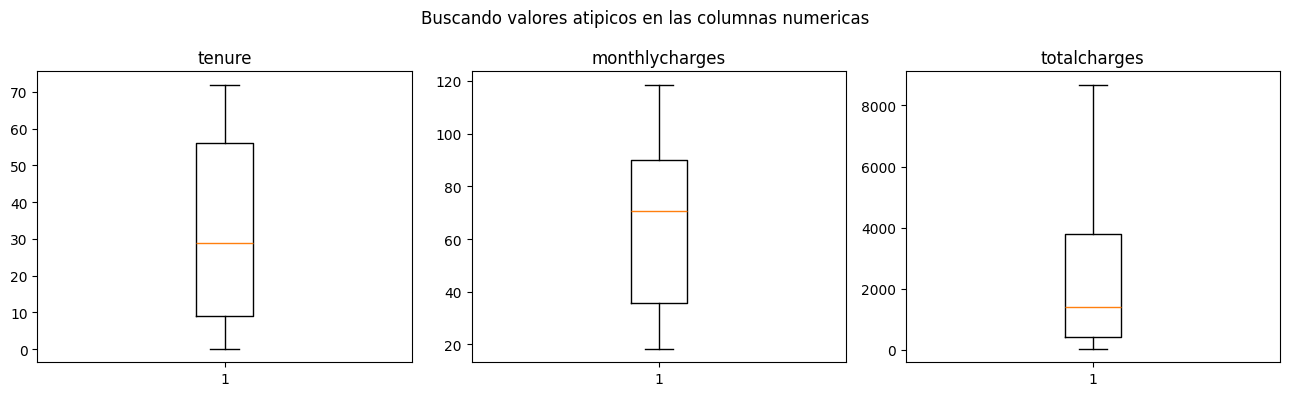

tenure           -> rango normal [   -61.5,    126.5]   atipicos: 0
monthlycharges   -> rango normal [   -45.5,    171.2]   atipicos: 0
totalcharges     -> rango normal [ -4688.5,   8884.7]   atipicos: 0


In [ ]:
import matplotlib.pyplot as plt

fig, ejes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(ejes, ["tenure", "monthlycharges", "totalcharges"]):
    ax.boxplot(df_limpio[col].dropna())
    ax.set_title(col)
plt.suptitle("Buscando valores atipicos en las columnas numericas")
plt.tight_layout()
plt.show()

for col in ["tenure", "monthlycharges", "totalcharges"]:
    q1, q3 = df_limpio[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_bajo, limite_alto = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    atipicos = ((df_limpio[col] < limite_bajo) | (df_limpio[col] > limite_alto)).sum()
    print(f"{col:16s} -> rango normal [{limite_bajo:8.1f}, {limite_alto:8.1f}]   atipicos: {atipicos}")

In [ ]:
print("Faltantes por columna (despues de los pasos 1 a 5):")
print(df_limpio.isna().sum().sort_values(ascending=False))
print()
total_celdas = df_limpio.shape[0] * df_limpio.shape[1]
total_vacias = df_limpio.isna().sum().sum()
print(f"Total: {total_vacias} celdas vacias de {total_celdas} ({total_vacias/total_celdas:.1%})")

Faltantes por columna (despues de los pasos 1 a 5):
tenure              2500
streamingtv         1500
monthlycharges      1500
internetservice     1000
partner             1000
gender               750
totalcharges          11
customerid             0
seniorcitizen          0
dependents             0
onlinesecurity         0
phoneservice           0
multiplelines          0
techsupport            0
deviceprotection       0
onlinebackup           0
streamingmovies        0
paperlessbilling       0
contract               0
paymentmethod          0
churn                  0
dtype: int64

Total: 8261 celdas vacias de 147903 (5.6%)


In [ ]:
# Verificacion rapida: ¿la tasa de churn es distinta entre filas con y sin dato faltante?
# Si NO es distinta, el faltante probablemente es aleatorio (no esconde un sesgo).
# Si SI es distinta, hay que ser mas cuidadosos: el faltante mismo es informacion.
for col in ["tenure", "monthlycharges", "gender", "partner", "internetservice", "streamingtv"]:
    falta = df_limpio[col].isna()
    tasa_falta = df_limpio.loc[falta, "churn"].eq("Yes").mean() * 100
    tasa_no_falta = df_limpio.loc[~falta, "churn"].eq("Yes").mean() * 100
    print(f"{col:18s} -> churn si falta: {tasa_falta:5.1f}%   churn si NO falta: {tasa_no_falta:5.1f}%")

tenure             -> churn si falta:  27.1%   churn si NO falta:  26.2%
monthlycharges     -> churn si falta:  26.5%   churn si NO falta:  26.5%
gender             -> churn si falta:  27.6%   churn si NO falta:  26.4%
partner            -> churn si falta:  26.5%   churn si NO falta:  26.5%
internetservice    -> churn si falta:  26.5%   churn si NO falta:  26.5%
streamingtv        -> churn si falta:  26.5%   churn si NO falta:  26.5%


In [ ]:
completos = df_limpio.dropna(subset=["tenure", "monthlycharges", "totalcharges"]).copy()
completos = completos[completos["monthlycharges"] > 0]
estimado = completos["totalcharges"] / completos["monthlycharges"]
diferencia = (estimado - completos["tenure"]).abs()

print("Diferencia entre tenure real y tenure estimado (en meses):")
print(diferencia.describe())
print(f"\nEn el {(diferencia < 2).mean():.0%} de los casos la estimacion queda a menos de 2 meses del valor real.")

Diferencia entre tenure real y tenure estimado (en meses):
count    4535.000000
mean        0.751817
std         0.809878
min         0.000000
25%         0.166741
50%         0.506494
75%         1.088368
max         7.407595
dtype: float64

En el 92% de los casos la estimacion queda a menos de 2 meses del valor real.


In [ ]:
recuperable = (
    df_limpio["tenure"].isna()
    & df_limpio["totalcharges"].notna()
    & df_limpio["monthlycharges"].notna()
    & (df_limpio["monthlycharges"] > 0)
)
print(f"tenure recuperado via totalcharges/monthlycharges: {recuperable.sum()} filas")

df_limpio.loc[recuperable, "tenure"] = (
    df_limpio.loc[recuperable, "totalcharges"] / df_limpio.loc[recuperable, "monthlycharges"]
).round()

print(f"tenure faltante restante: {df_limpio['tenure'].isna().sum()}")

tenure recuperado via totalcharges/monthlycharges: 999 filas
tenure faltante restante: 1501


In [ ]:
print("Mediana de tenure por tipo de contrato:")
print(df_limpio.groupby("contract")["tenure"].median())

df_limpio["tenure"] = df_limpio.groupby("contract")["tenure"].transform(
    lambda serie: serie.fillna(serie.median())
)

print(f"\ntenure faltante restante: {df_limpio['tenure'].isna().sum()}")

Mediana de tenure por tipo de contrato:
contract
Month-to-month    12.0
One year          43.5
Two year          64.0
Name: tenure, dtype: float64

tenure faltante restante: 0


In [ ]:
print("Mediana de monthlycharges por internetservice:")
print(df_limpio.groupby("internetservice")["monthlycharges"].median())

df_limpio["monthlycharges"] = df_limpio.groupby("internetservice")["monthlycharges"].transform(
    lambda serie: serie.fillna(serie.median())
)

df_limpio["monthlycharges"] = df_limpio["monthlycharges"].fillna(df_limpio["monthlycharges"].median())

print(f"\nmonthlycharges faltante restante: {df_limpio['monthlycharges'].isna().sum()}")

Mediana de monthlycharges por internetservice:
internetservice
DSL            56.075
Fiber optic    92.050
No             20.150
Name: monthlycharges, dtype: float64

monthlycharges faltante restante: 0


In [ ]:
pendientes = df_limpio["totalcharges"].isna()
print(f"totalcharges aun faltante: {pendientes.sum()}")
print(df_limpio.loc[pendientes, ["customerid", "tenure", "monthlycharges", "totalcharges"]])

# Se recalcula con lo que ya sabemos: tenure * tarifa mensual
df_limpio.loc[pendientes, "totalcharges"] = (
    df_limpio.loc[pendientes, "tenure"] * df_limpio.loc[pendientes, "monthlycharges"]
)
print(f"\ntotalcharges faltante restante: {df_limpio['totalcharges'].isna().sum()}")

totalcharges aun faltante: 11
      customerid  tenure  monthlycharges  totalcharges
488   4472-LVYGI     0.0          52.550           NaN
753   3115-CZMZD     0.0          20.250           NaN
936   5709-LVOEQ     0.0          80.850           NaN
1082  4367-NUYAO     0.0          25.750           NaN
1340  1371-DWPAZ    64.0          56.050           NaN
3331  7644-OMVMY     0.0          19.850           NaN
3826  3213-VVOLG     0.0          25.350           NaN
4380  2520-SGTTA     0.0          20.000           NaN
5218  2923-ARZLG     0.0          19.700           NaN
6670  4075-WKNIU    64.0          70.300           NaN
6754  2775-SEFEE    64.0          56.075           NaN

totalcharges faltante restante: 0


In [ ]:
columnas_sin_predictor = ["gender", "partner", "internetservice", "streamingtv"]

for col in columnas_sin_predictor:
    df_limpio[col] = df_limpio[col].fillna("No registrado")

print("Faltantes finales en todo el DataFrame:")
print(df_limpio.isna().sum().sum())

Faltantes finales en todo el DataFrame:
0


In [ ]:
# COMPARACION CRUDO VS LIMPIO

print("=" * 62)
print("CRUDO vs LIMPIO")
print("=" * 62)
print(f"Filas                         : {df.shape[0]}  ->  {df_limpio.shape[0]}")
print(f"Columnas                      : {df.shape[1]}  ->  {df_limpio.shape[1]}")
print(f"Celdas vacias                 : {df.isna().sum().sum()}  ->  {df_limpio.isna().sum().sum()}")
print(f"Tipo de 'totalcharges'        : {df['TotalCharges'].dtype}  ->  {df_limpio['totalcharges'].dtype}")
print(f"Tasa de churn (Yes)           : {df['Churn'].eq('Yes').mean():.2%}  ->  {df_limpio['churn'].eq('Yes').mean():.2%}")
print(f"Promedio de tenure            : {df['tenure'].mean():.1f} meses  ->  {df_limpio['tenure'].mean():.1f} meses")
print(f"Promedio de monthlycharges    : {df['MonthlyCharges'].mean():.2f}  ->  {df_limpio['monthlycharges'].mean():.2f}")

CRUDO vs LIMPIO
Filas                         : 7043  ->  7043
Columnas                      : 21  ->  21
Celdas vacias                 : 8250  ->  0
Tipo de 'totalcharges'        : object  ->  float64
Tasa de churn (Yes)           : 26.54%  ->  26.54%
Promedio de tenure            : 32.5 meses  ->  32.1 meses
Promedio de monthlycharges    : 64.88  ->  65.59


In [ ]:
# QUE HUBIERA PASADO SI EN VEZ DE LIMPIAR LOS DATOS VACIOS, LOS HUBIERAMOS IGNORADO

crudo_convertido = df.copy()
crudo_convertido["TotalCharges"] = pd.to_numeric(crudo_convertido["TotalCharges"], errors="coerce")

dropna_ingenuo = crudo_convertido.dropna()

print(f"Filas si se hace dropna() directo sobre el crudo : {len(dropna_ingenuo)} de {len(df)}"
      f" (se pierde el {(1 - len(dropna_ingenuo)/len(df)):.1%} de los datos)")
print(f"Filas con nuestra limpieza                        : {len(df_limpio)} de {len(df)}"
      f" (se pierde el {(1 - len(df_limpio)/len(df)):.1%} de los datos)")

print(f"\nTasa de churn con dropna() ingenuo  : {dropna_ingenuo['Churn'].eq('Yes').mean():.2%}")
print(f"Tasa de churn con nuestra limpieza  : {df_limpio['churn'].eq('Yes').mean():.2%}")

Filas si se hace dropna() directo sobre el crudo : 4535 de 7043 (se pierde el 35.6% de los datos)
Filas con nuestra limpieza                        : 7043 de 7043 (se pierde el 0.0% de los datos)

Tasa de churn con dropna() ingenuo  : 26.26%
Tasa de churn con nuestra limpieza  : 26.54%


In [ ]:
# GUARDAMOS EL RESULTADO Y LA BITACORA

ruta_salida = "/content/drive/MyDrive/DataXperience Proyecto/telco_data_limpio.csv"
df_limpio.to_csv(ruta_salida, index=False, encoding="utf-8")
print(f"Archivo limpio guardado en: {ruta_salida}")

print("\n" + "=" * 62)
print("BITACORA DE LIMPIEZA - telco_data.csv -> telco_data_limpio.csv")
print("=" * 62)
print(f"Filas iniciales              : {df.shape[0]}")
print(f"Filas finales                : {df_limpio.shape[0]}")
print(f"Filas descartadas            : {df.shape[0] - df_limpio.shape[0]}")
print(f"Celdas vacias al iniciar     : {df.isna().sum().sum()}")
print(f"Celdas vacias al terminar    : {df_limpio.isna().sum().sum()}")
print("-" * 62)
print("Decisiones tomadas:")
print("  1. Nombres de columnas pasados a minuscula (ej. SeniorCitizen -> seniorcitizen).")
print("  2. Se verificaron duplicados exactos y por customerID: no se encontro ninguno.")
print("  3. Se verificaron espacios y mayusculas en columnas de texto: ya venian limpias.")
print("  4. Se verificaron categorias equivalentes: ya venian consistentes, no se unifico nada.")
print("  5. 'totalcharges' se convirtio de texto a numero (11 celdas en blanco -> NaN).")
print("  6. Se revisaron rangos imposibles (tenure, cargos, senior_citizen): no se encontraron.")
print("  7. totalcharges: 9 filas con tenure=0 se llenaron con 0 (clientes nuevos sin facturar).")
print("  8. tenure: 999 filas se recuperaron con totalcharges/monthlycharges (formula validada).")
print("  9. tenure: 1501 filas restantes se llenaron con la mediana por tipo de contrato.")
print(" 10. monthlycharges: 1500 filas se llenaron con la mediana por tipo de internet.")
print(" 11. totalcharges: filas restantes se recalcularon con tenure * monthlycharges.")
print(" 12. gender, partner, internetservice, streamingtv: faltantes marcados como 'No registrado'")
print("     (no existia una columna confiable para adivinar estos valores).")
print("=" * 62)

Archivo limpio guardado en: /content/drive/MyDrive/DataXperience Proyecto/telco_data_limpio.csv

BITACORA DE LIMPIEZA - telco_data.csv -> telco_data_limpio.csv
Filas iniciales              : 7043
Filas finales                : 7043
Filas descartadas            : 0
Celdas vacias al iniciar     : 8250
Celdas vacias al terminar    : 0
--------------------------------------------------------------
Decisiones tomadas:
  1. Nombres de columnas pasados a minuscula (ej. SeniorCitizen -> seniorcitizen).
  2. Se verificaron duplicados exactos y por customerID: no se encontro ninguno.
  3. Se verificaron espacios y mayusculas en columnas de texto: ya venian limpias.
  4. Se verificaron categorias equivalentes: ya venian consistentes, no se unifico nada.
  5. 'totalcharges' se convirtio de texto a numero (11 celdas en blanco -> NaN).
  6. Se revisaron rangos imposibles (tenure, cargos, senior_citizen): no se encontraron.
  7. totalcharges: 9 filas con tenure=0 se llenaron con 0 (clientes nuevos si

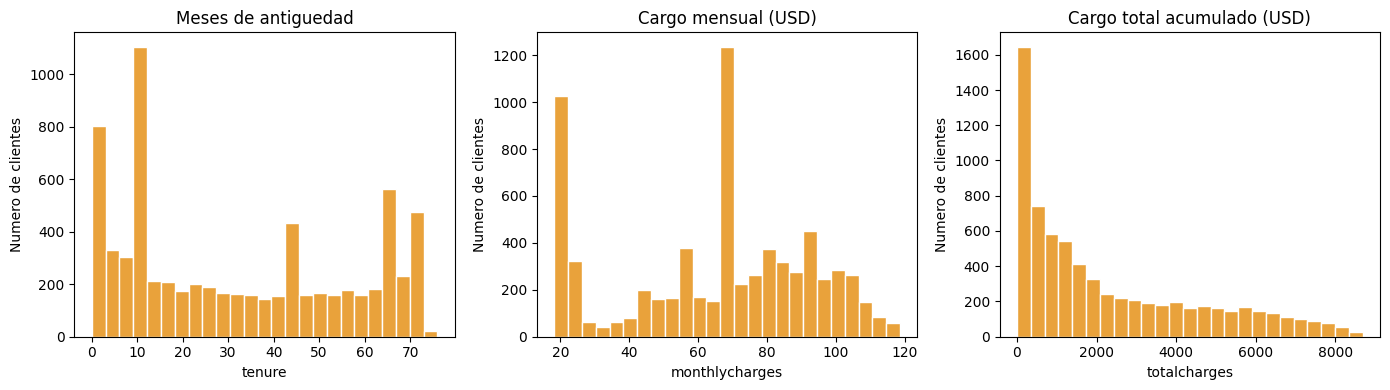

In [ ]:
# ANALISIS EXPLORATORIO (GRAFICAS)

import matplotlib.pyplot as plt

fig, ejes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, titulo in zip(
    ejes,
    ["tenure", "monthlycharges", "totalcharges"],
    ["Meses de antiguedad", "Cargo mensual (USD)", "Cargo total acumulado (USD)"],
):
    ax.hist(df_limpio[col], bins=25, color="#E9A23B", edgecolor="white")
    ax.set_title(titulo)
    ax.set_xlabel(col)
    ax.set_ylabel("Numero de clientes")
plt.tight_layout()
plt.show()

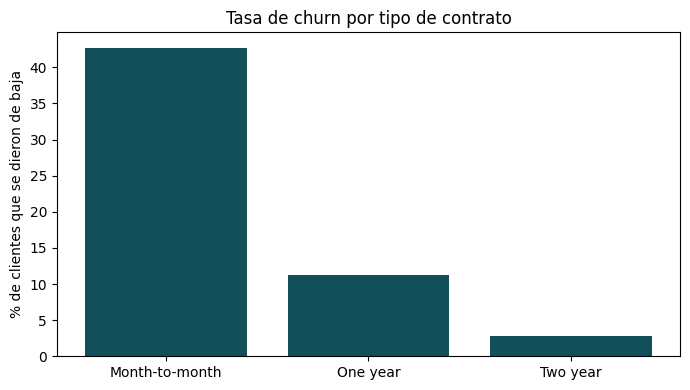

contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: churn, dtype: float64


In [ ]:
tasa_por_contrato = (
    df_limpio.groupby("contract")["churn"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
plt.bar(tasa_por_contrato.index, tasa_por_contrato.values, color="#124F5A")
plt.title("Tasa de churn por tipo de contrato")
plt.ylabel("% de clientes que se dieron de baja")
plt.tight_layout()
plt.show()

print(tasa_por_contrato.round(1))

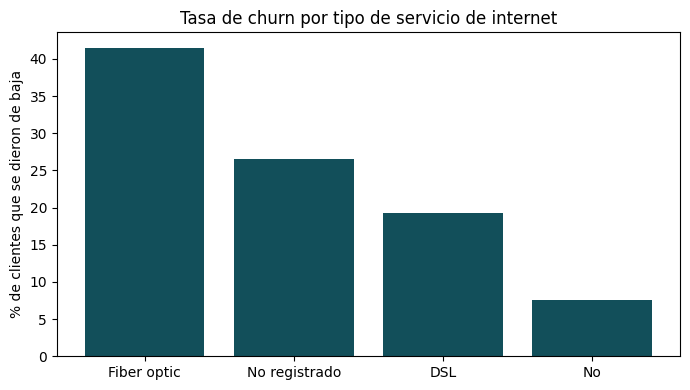

internetservice
Fiber optic      41.5
No registrado    26.5
DSL              19.3
No                7.6
Name: churn, dtype: float64


In [ ]:
tasa_por_internet = (
    df_limpio.groupby("internetservice")["churn"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
plt.bar(tasa_por_internet.index, tasa_por_internet.values, color="#124F5A")
plt.title("Tasa de churn por tipo de servicio de internet")
plt.ylabel("% de clientes que se dieron de baja")
plt.tight_layout()
plt.show()

print(tasa_por_internet.round(1))

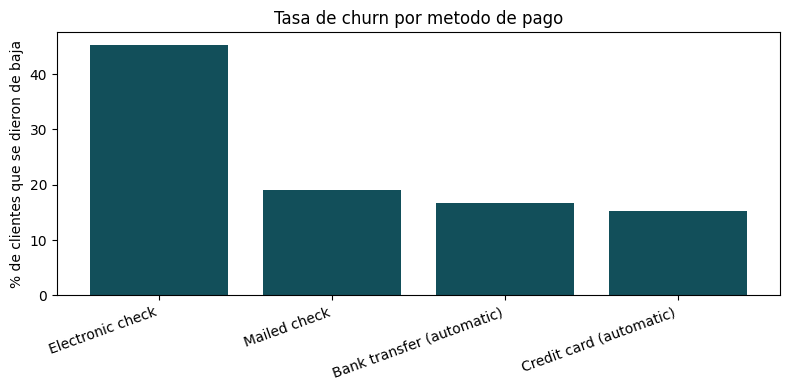

paymentmethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: churn, dtype: float64


In [ ]:
tasa_por_pago = (
    df_limpio.groupby("paymentmethod")["churn"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
plt.bar(tasa_por_pago.index, tasa_por_pago.values, color="#124F5A")
plt.title("Tasa de churn por metodo de pago")
plt.ylabel("% de clientes que se dieron de baja")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print(tasa_por_pago.round(1))

       tenure  monthlycharges  totalcharges
churn                                      
No       37.3            62.5        2552.2
Yes      17.8            74.0        1531.8


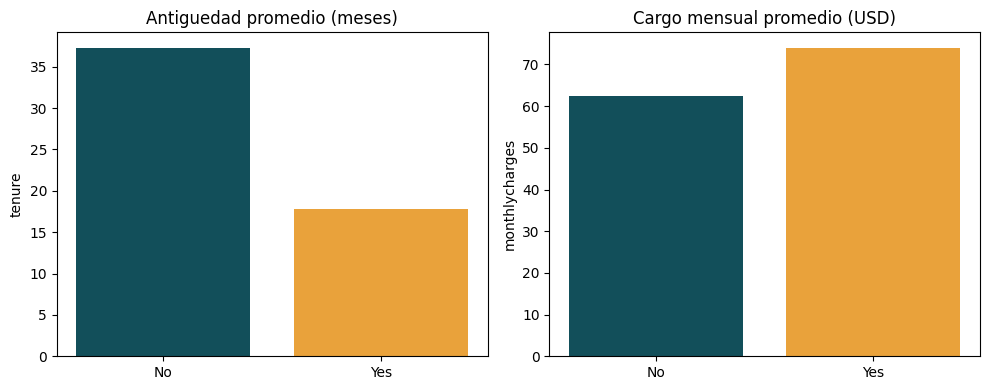

In [ ]:
resumen = df_limpio.groupby("churn")[["tenure", "monthlycharges", "totalcharges"]].mean().round(1)
print(resumen)

fig, ejes = plt.subplots(1, 2, figsize=(10, 4))

ejes[0].bar(resumen.index, resumen["tenure"], color=["#124F5A", "#E9A23B"])
ejes[0].set_title("Antiguedad promedio (meses)")
ejes[0].set_ylabel("tenure")

ejes[1].bar(resumen.index, resumen["monthlycharges"], color=["#124F5A", "#E9A23B"])
ejes[1].set_title("Cargo mensual promedio (USD)")
ejes[1].set_ylabel("monthlycharges")

plt.tight_layout()
plt.show()

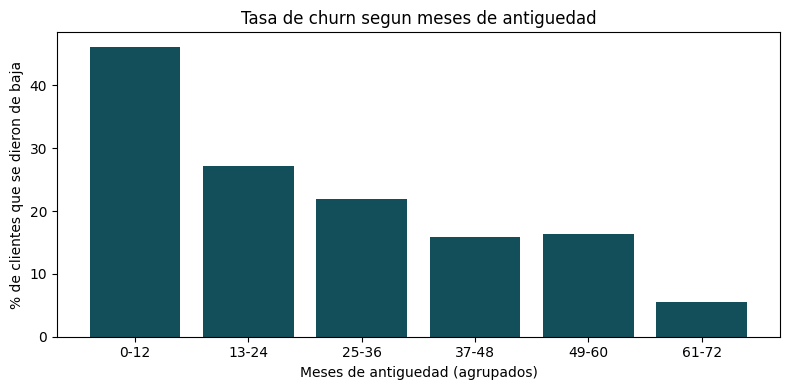

grupo_tenure
0-12     46.1
13-24    27.1
25-36    21.9
37-48    15.8
49-60    16.3
61-72     5.5
Name: churn, dtype: float64


In [ ]:
bins = [0, 12, 24, 36, 48, 60, 73]
etiquetas = ["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
df_limpio["grupo_tenure"] = pd.cut(df_limpio["tenure"], bins=bins, labels=etiquetas, include_lowest=True)

tasa_por_tenure = df_limpio.groupby("grupo_tenure", observed=True)["churn"].apply(
    lambda s: (s == "Yes").mean() * 100
)

plt.figure(figsize=(8, 4))
plt.bar(tasa_por_tenure.index.astype(str), tasa_por_tenure.values, color="#124F5A")
plt.title("Tasa de churn segun meses de antiguedad")
plt.xlabel("Meses de antiguedad (agrupados)")
plt.ylabel("% de clientes que se dieron de baja")
plt.tight_layout()
plt.show()

print(tasa_por_tenure.round(1))

In [ ]:
"Importar librerias"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
"Carga de archivos"
from google.colab import files

uploaded = files.upload()

Saving telco_data.csv to telco_data.csv


In [ ]:
df_crudo = pd.read_csv('telco_data.csv')
"Tamaño de bases"

print("BASE ORIGINAL")
print("Filas:", df_crudo.shape[0])
print("Columnas:", df_crudo.shape[1])

print("\nBASE LIMPIA")
print("Filas:", df_limpio.shape[0])
print("Columnas:", df_limpio.shape[1])

"""La limpieza no eliminó registros ni variables; el objetivo fue
mejorar la calidad y consistencia de los datos conservando la
totalidad de la información disponible."""

BASE ORIGINAL
Filas: 7043
Columnas: 21

BASE LIMPIA
Filas: 7043
Columnas: 22


'La limpieza no eliminó registros ni variables; el objetivo fue\nmejorar la calidad y consistencia de los datos conservando la\ntotalidad de la información disponible.'

In [ ]:
# Tabla comparativa de las bases de datos

tabla_datos = pd.DataFrame({
    'Característica': [
        'Registros',
        'Variables originales',
        'Valores faltantes',
        'Registros duplicados'
    ],

    'Base original': [
        df_crudo.shape[0],
        21,
        df_crudo.isnull().sum().sum(),
        df_crudo.duplicated().sum()
    ],

    'Base limpia': [
        df_limpio.shape[0],
        21,
        df_limpio.isnull().sum().sum(),
        df_limpio.duplicated().sum()
    ]
})

tabla_datos

,Característica,Base original,Base limpia
0,Registros,7043,7043
1,Variables originales,21,21
2,Valores faltantes,8250,7
3,Registros duplicados,0,0


In [ ]:
"Cinco primeras filas del dataframe original"
df_crudo.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
"Cinco primeras filas del dataframe limpio "
df_limpio.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,grupo_tenure
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12


In [ ]:
"Tabla mostrando variables que tenian valores faltantes, cuantos y que porcentaje"

faltantes = pd.DataFrame({
    'Cantidad': df_crudo.isnull().sum(),
    'Porcentaje': df_crudo.isnull().mean() * 100
})

faltantes = faltantes[faltantes['Cantidad'] > 0]
faltantes = faltantes.sort_values('Cantidad', ascending=False)

faltantes

,Cantidad,Porcentaje
tenure,2500,35.496237
StreamingTV,1500,21.297742
MonthlyCharges,1500,21.297742
Partner,1000,14.198495
InternetService,1000,14.198495
gender,750,10.648871


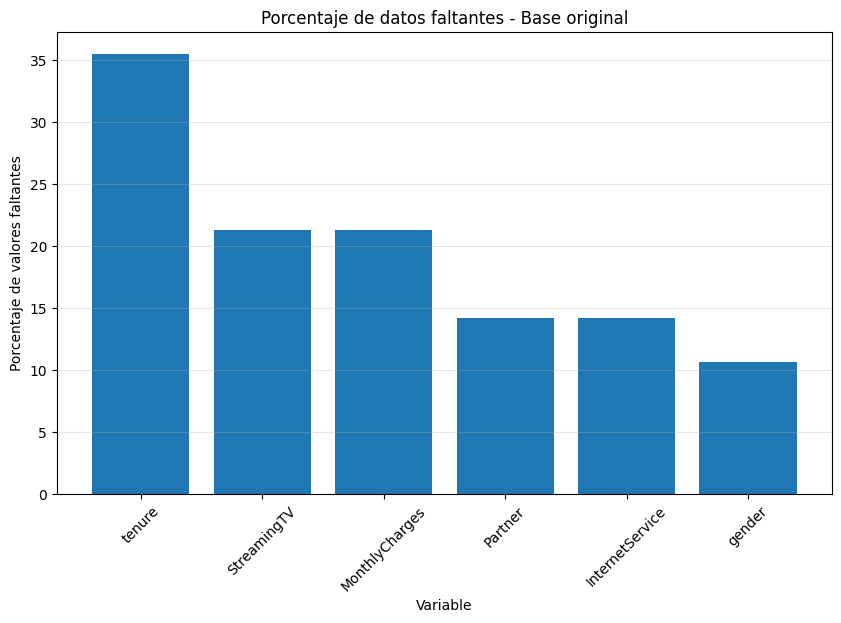

'Antes de realizar cualquier análisis exploratorio fue necesario\nevaluar la calidad de los datos. Se identificó que algunas variables\npresentaban una proporción considerable de valores faltantes.\nEl caso más crítico fue tenure (cantidad de meses que el cliente\nlleva siendo cliente de la empresa), donde aproximadamente el 35,5 %\nde los registros no tenía información. Trabajar directamente con\nestos datos habría reducido considerablemente la cantidad de observaciones\ndisponibles para determinados análisis.'

In [ ]:
"Grafica de barras donde aparece la varible con mayor cantidad de datos faltantes"

plt.figure(figsize=(10,6))

plt.bar(faltantes.index, faltantes['Porcentaje'])

plt.title('Porcentaje de datos faltantes - Base original')
plt.xlabel('Variable')
plt.ylabel('Porcentaje de valores faltantes')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

"""Antes de realizar cualquier análisis exploratorio fue necesario
evaluar la calidad de los datos. Se identificó que algunas variables
presentaban una proporción considerable de valores faltantes.
El caso más crítico fue tenure (cantidad de meses que el cliente
lleva siendo cliente de la empresa), donde aproximadamente el 35,5 %
de los registros no tenía información. Trabajar directamente con
estos datos habría reducido considerablemente la cantidad de observaciones
disponibles para determinados análisis."""

In [ ]:
"""En esta tabla comparamos la cantidad de valores faltantes antes
y después del proceso de limpieza. En la base original encontramos
problemas especialmente importantes en variables como tenure, que
presentaba 2.500 registros sin información, y streamingtv y monthlycharges,
con 1.500 registros faltantes cada una. Después del proceso de limpieza,
estas variables pasan a tener cero valores faltantes. Esto demuestra que
el proceso permitió aumentar la disponibilidad de información sin
eliminar los registros de la base"""

comparacion_faltantes = pd.DataFrame({
    'Original': df_crudo.isnull().sum(),
    'Limpia': df_limpio.isnull().sum()
})

comparacion_faltantes = comparacion_faltantes[
    (comparacion_faltantes['Original'] > 0) |
    (comparacion_faltantes['Limpia'] > 0)
]

comparacion_faltantes



,Original,Limpia
InternetService,1000.0,NaN
MonthlyCharges,1500.0,NaN
Partner,1000.0,NaN
StreamingTV,1500.0,NaN
gender,750.0,0.0
grupo_tenure,NaN,7.0
tenure,2500.0,0.0


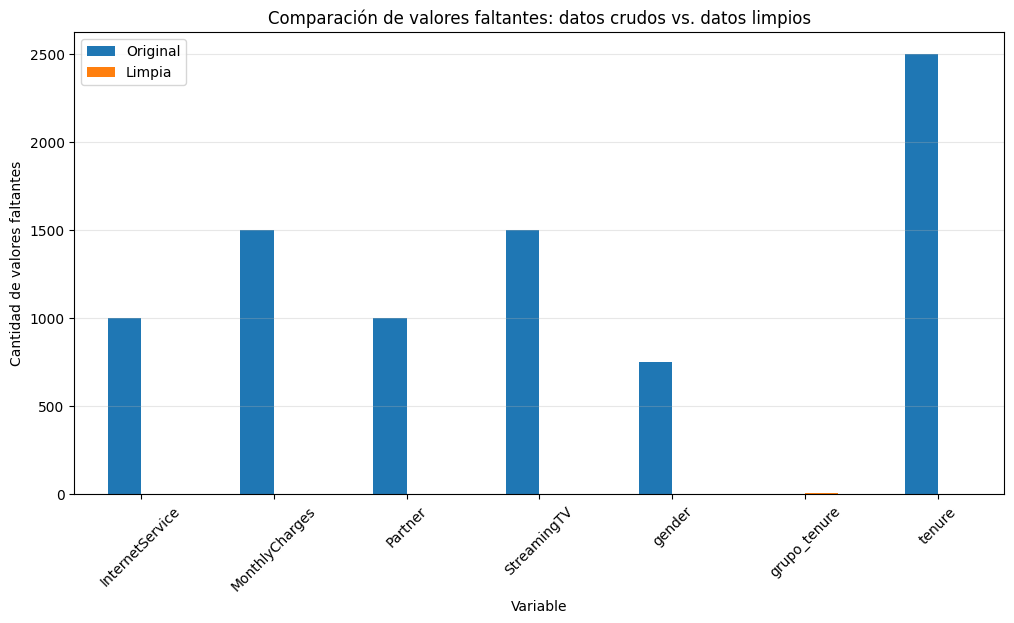

In [ ]:
comparacion_faltantes.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Comparación de valores faltantes: datos crudos vs. datos limpios')
plt.xlabel('Variable')
plt.ylabel('Cantidad de valores faltantes')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()



In [ ]:
print("GENDER ORIGINAL")
print(df_crudo['gender'].value_counts(dropna=False))

print("\nGENDER LIMPIO")
print(df_limpio['gender'].value_counts(dropna=False))

GENDER ORIGINAL
gender
Male      3202
Female    3091
NaN        750
Name: count, dtype: int64

GENDER LIMPIO
gender
Male             3202
Female           3091
No registrado     750
Name: count, dtype: int64


In [ ]:
"""Se optienen todos los nombres de las columnas"""

df_crudo.columns = (
    df_crudo.columns
    .str.strip()
    .str.lower()
)

df_limpio.columns = (
    df_limpio.columns
    .str.strip()
    .str.lower()
)

print("Columnas de la BASE ORIGINAL:")
print(df_crudo.columns.tolist())

print("\nColumnas de la BASE LIMPIA:")
print(df_limpio.columns.tolist())

Columnas de la BASE ORIGINAL:
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']

Columnas de la BASE LIMPIA:
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn', 'grupo_tenure']


In [ ]:
variables_categoricas = [
    'gender',
    'partner',
    'internetservice',
    'streamingtv'
]

for variable in variables_categoricas:

    print("\n" + "="*50)
    print(variable.upper())
    print("="*50)

    print("\nORIGINAL:")
    print(df_crudo[variable].value_counts(dropna=False))

    print("\nLIMPIA:")
    print(df_limpio[variable].value_counts(dropna=False))


GENDER

ORIGINAL:
gender
Male      3202
Female    3091
NaN        750
Name: count, dtype: int64

LIMPIA:
gender
Male             3202
Female           3091
No registrado     750
Name: count, dtype: int64

PARTNER

ORIGINAL:
partner
No     3115
Yes    2928
NaN    1000
Name: count, dtype: int64

LIMPIA:
partner
No               3115
Yes              2928
No registrado    1000
Name: count, dtype: int64

INTERNETSERVICE

ORIGINAL:
internetservice
Fiber optic    2660
DSL            2082
No             1301
NaN            1000
Name: count, dtype: int64

LIMPIA:
internetservice
Fiber optic      2660
DSL              2082
No               1301
No registrado    1000
Name: count, dtype: int64

STREAMINGTV

ORIGINAL:
streamingtv
No                     2199
Yes                    2146
NaN                    1500
No internet service    1198
Name: count, dtype: int64

LIMPIA:
streamingtv
No                     2199
Yes                    2146
No registrado          1500
No internet service    1198


In [ ]:
print(df_crudo['totalcharges'].dtype)

object


In [ ]:
print(df_limpio['totalcharges'].dtype)

float64


In [ ]:
"""Regitros donde el numero no podia interpretarse correctamente"""

totalcharges_numerico = pd.to_numeric(
    df_crudo['totalcharges'],
    errors='coerce'
)

problemas_totalcharges = df_crudo[
    totalcharges_numerico.isna()
]

problemas_totalcharges[['customerid', 'tenure', 'totalcharges']]

,customerid,tenure,totalcharges
488,4472-LVYGI,0.0,
753,3115-CZMZD,0.0,
936,5709-LVOEQ,0.0,
1082,4367-NUYAO,0.0,
1340,1371-DWPAZ,NaN,
3331,7644-OMVMY,0.0,
3826,3213-VVOLG,0.0,
4380,2520-SGTTA,0.0,
5218,2923-ARZLG,0.0,
6670,4075-WKNIU,NaN,


In [ ]:
print("NaN en TotalCharges - ORIGINAL:")
print(df_crudo['totalcharges'].isna().sum())

print("\nNaN en TotalCharges - LIMPIA:")
print(df_limpio['totalcharges'].isna().sum())

NaN en TotalCharges - ORIGINAL:
0

NaN en TotalCharges - LIMPIA:
0


In [ ]:
"""Muestra los registros que no podian convertirse en numericos"""
df_limpio.loc[
    totalcharges_numerico.isna(),
    ['customerid', 'tenure', 'totalcharges']
]

,customerid,tenure,totalcharges
488,4472-LVYGI,0.0,0.0
753,3115-CZMZD,0.0,0.0
936,5709-LVOEQ,0.0,0.0
1082,4367-NUYAO,0.0,0.0
1340,1371-DWPAZ,64.0,3587.2
3331,7644-OMVMY,0.0,0.0
3826,3213-VVOLG,0.0,0.0
4380,2520-SGTTA,0.0,0.0
5218,2923-ARZLG,0.0,0.0
6670,4075-WKNIU,64.0,4499.2


Estos clientes tienen 64 meses de antigüedad, pero originalmente totalcharges no tenía un valor interpretable.

Eso significa que el proceso de limpieza tuvo que tomar una decisión sobre qué hacer con esos datos faltantes.

Se identificaron 11 registros cuyo valor de TotalCharges no podía interpretarse como numérico. Durante la limpieza estos valores fueron tratados y convertidos a valores numéricos, pero el tratamiento debe considerarse al interpretar posteriormente esta variable, ya que convertir un valor faltante en 0 implica asumir que no existía un cargo registrado."

In [ ]:
print("Original:")
print(df_crudo['monthlycharges'].describe())

print("\nLimpia:")
print(df_limpio['monthlycharges'].describe())

Original:
count    5543.000000
mean       64.876403
std        30.101331
min        18.250000
25%        35.750000
50%        70.550000
75%        89.925000
max       118.600000
Name: monthlycharges, dtype: float64

Limpia:
count    7043.000000
mean       65.594455
std        27.758845
min        18.250000
25%        45.750000
50%        70.300000
75%        87.850000
max       118.600000
Name: monthlycharges, dtype: float64


In [ ]:
mask = df_crudo['monthlycharges'].isna()

comparacion_monthly = pd.DataFrame({
    'internetservice': df_limpio.loc[mask, 'internetservice'],
    'monthlycharges_asignado': df_limpio.loc[mask, 'monthlycharges']
})

comparacion_monthly.groupby(
    ['internetservice', 'monthlycharges_asignado']
).size().reset_index(name='cantidad')

,internetservice,monthlycharges_asignado,cantidad
0,DSL,56.075,182
1,Fiber optic,92.050,215
2,No,20.150,103
3,No registrado,70.300,1000


En esta gráfica analizamos específicamente los 1.500 registros que originalmente no tenían información en MonthlyCharges. Observamos que la mayor parte, 1.000 registros, corresponde a clientes cuyo servicio de Internet tampoco estaba registrado. Los restantes valores se distribuyeron entre DSL, fibra óptica y clientes sin servicio de Internet. Esto nos permitió conservar estos registros para el análisis, aunque debemos tener en cuenta que los valores imputados no corresponden necesariamente al valor real que tenía cada cliente.

In [ ]:
print("Mediana de tenure por tipo de contrato:")
print(df_crudo.groupby('contract')['tenure'].median())

Mediana de tenure por tipo de contrato:
contract
Month-to-month    12.0
One year          43.0
Two year          64.0
Name: tenure, dtype: float64


Month-to-month → 12 meses

One year → 43 meses

Two year → 64 meses

In [ ]:
mask = df_crudo['tenure'].isna()

df_tenure = pd.DataFrame({
    'contract': df_crudo.loc[mask, 'contract'],
    'tenure_imputado': df_limpio.loc[mask, 'tenure']
})

df_tenure.groupby(
    ['contract', 'tenure_imputado']
).size().reset_index(name='cantidad').sort_values(
    ['contract', 'cantidad'],
    ascending=[True, False]
).head(30)

,contract,tenure_imputado,cantidad
11,Month-to-month,12.0,848
0,Month-to-month,1.0,87
1,Month-to-month,2.0,28
2,Month-to-month,3.0,26
3,Month-to-month,4.0,24
6,Month-to-month,7.0,24
4,Month-to-month,5.0,18
7,Month-to-month,8.0,14
8,Month-to-month,9.0,14
16,Month-to-month,17.0,13


tenure = cantidad de meses que el cliente lleva con la empresa.

Por ejemplo, tenure = 12 significa que lleva 12 meses, es decir, aproximadamente un año.

Tenure fue una de las variables con mayor cantidad de datos faltantes, con 2.500 registros. Para analizar cómo fueron tratados, relacionamos los valores imputados con el tipo de contrato del cliente. Encontramos que para los clientes con contrato mensual el valor de 12 meses fue el más frecuente, con 848 registros. Esto es consistente con el uso de una medida de tendencia central, como la mediana del grupo, para realizar la imputación. De esta manera, no se utilizó necesariamente un único valor para todos los clientes, sino que se tuvo en cuenta información disponible en otras variables."

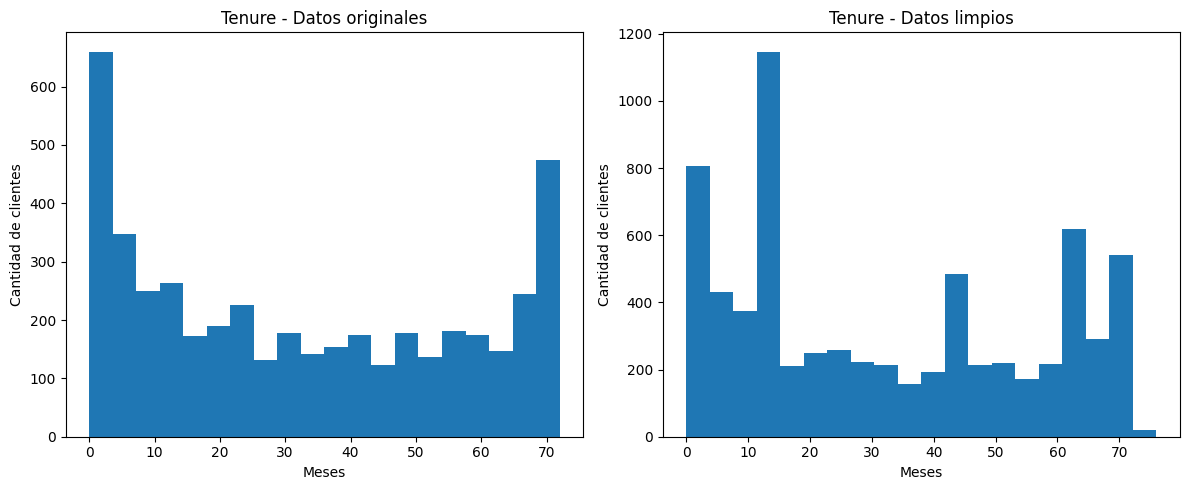

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df_crudo['tenure'].dropna(), bins=20)
plt.title('Tenure - Datos originales')
plt.xlabel('Meses')
plt.ylabel('Cantidad de clientes')

plt.subplot(1,2,2)
plt.hist(df_limpio['tenure'], bins=20)
plt.title('Tenure - Datos limpios')
plt.xlabel('Meses')
plt.ylabel('Cantidad de clientes')

plt.tight_layout()
plt.show()

La limpieza permitió trabajar con el 100 % de los registros para esta variable, pero también modificó su distribución. Por esta razón, la imputación no debe verse únicamente como una forma de eliminar valores vacíos, sino como una decisión que puede tener efectos sobre los resultados posteriores.

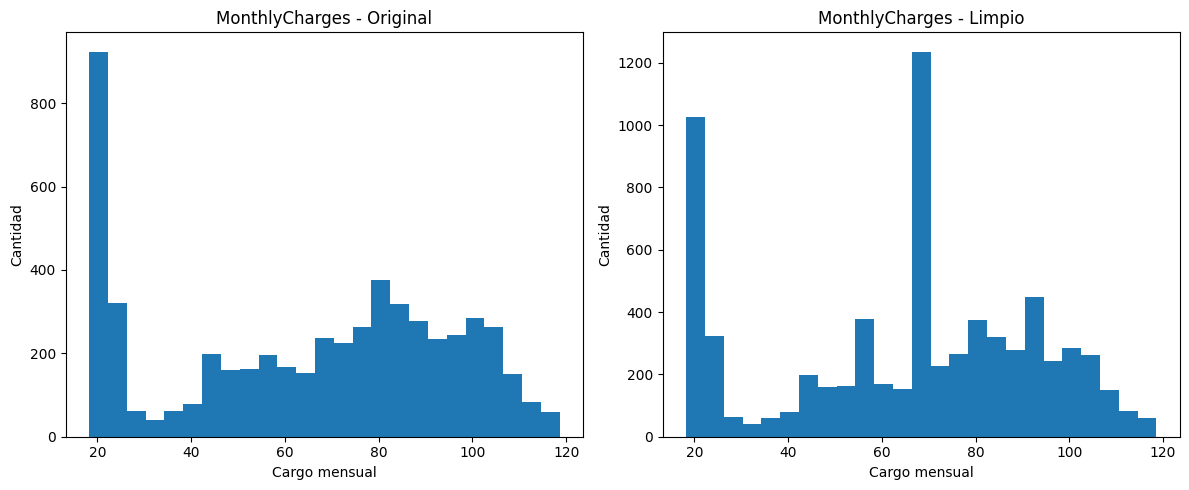

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df_crudo['monthlycharges'].dropna(), bins=25)
plt.title('MonthlyCharges - Original')
plt.xlabel('Cargo mensual')
plt.ylabel('Cantidad')

plt.subplot(1,2,2)
plt.hist(df_limpio['monthlycharges'], bins=25)
plt.title('MonthlyCharges - Limpio')
plt.xlabel('Cargo mensual')
plt.ylabel('Cantidad')

plt.tight_layout()
plt.show()

En esta comparación observamos la distribución de MonthlyCharges antes y después de la limpieza. En la base original existían 1.500 valores faltantes, por lo que el primer histograma solamente representa los registros que tenían información disponible. Después de la limpieza se incorporaron los valores tratados, aumentando la cantidad de información disponible. Sin embargo, podemos observar que aparecen concentraciones más marcadas alrededor de determinados valores. Esto se debe al proceso de imputación, que asignó valores específicos a los registros faltantes. Por lo tanto, la limpieza permitió completar la base, pero también modificó parcialmente la distribución de la variable, algo que debemos considerar al interpretar los resultados.

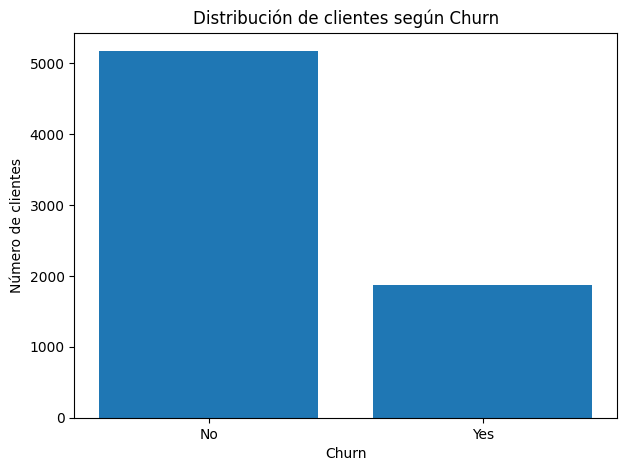

churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentajes:
churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
churn = df_limpio['churn'].value_counts()

plt.figure(figsize=(7,5))

plt.bar(churn.index, churn.values)

plt.title('Distribución de clientes según Churn')
plt.xlabel('Churn')
plt.ylabel('Número de clientes')

plt.show()

print(churn)
print("\nPorcentajes:")
print(df_limpio['churn'].value_counts(normalize=True) * 100)

In [ ]:
tabla_contrato = pd.crosstab(
    df_limpio['contract'],
    df_limpio['churn'],
    normalize='index'
) * 100

tabla_contrato

churn,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


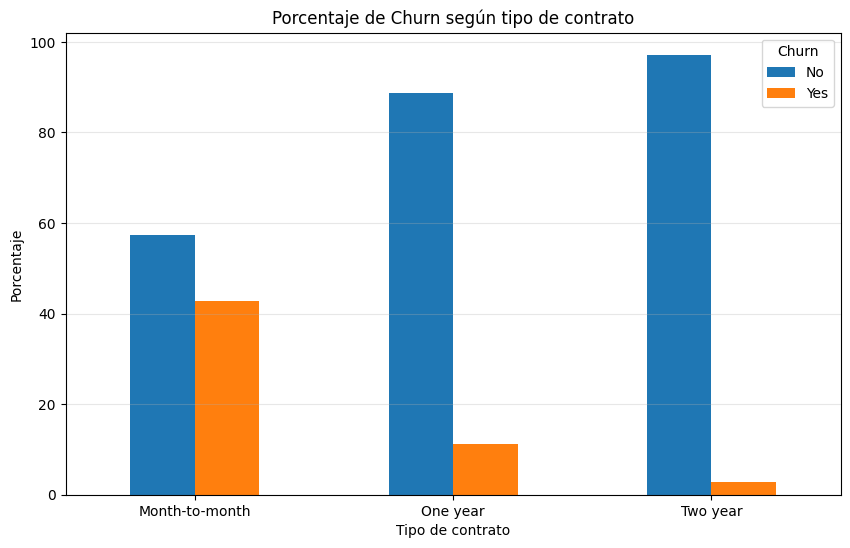

In [ ]:
tabla_contrato.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Porcentaje de Churn según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.grid(axis='y', alpha=0.3)

plt.show()

Se observa una relación clara entre la duración del contrato y la permanencia del cliente. Los usuarios con contratos mes a mes presentan una tasa de abandono considerablemente mayor que aquellos con contratos de uno o dos años.

In [ ]:
tabla_internet = pd.crosstab(
    df_limpio['internetservice'],
    df_limpio['churn'],
    normalize='index'
) * 100

tabla_internet

churn,No,Yes
internetservice,,
DSL,80.739673,19.260327
Fiber optic,58.496241,41.503759
No,92.390469,7.609531
No registrado,73.500000,26.500000


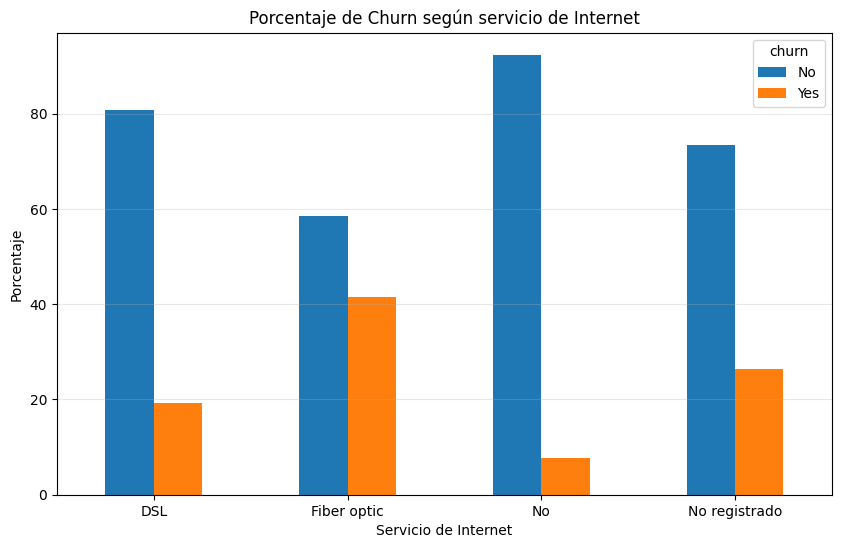

In [ ]:
tabla_internet.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Porcentaje de Churn según servicio de Internet')
plt.xlabel('Servicio de Internet')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
"""Clasificacion de clientes segun antiguedad: Nueva variable"""

bins = [-1, 6, 12, 24, 48, 72, 100]

labels = [
    '0-6 meses',
    '7-12 meses',
    '13-24 meses',
    '25-48 meses',
    '49-72 meses',
    '73+ meses'
]

df_limpio['grupo_tenure'] = pd.cut(
    df_limpio['tenure'],
    bins=bins,
    labels=labels
)

In [ ]:
churn_tenure = pd.crosstab(
    df_limpio['grupo_tenure'],
    df_limpio['churn'],
    normalize='index'
) * 100

churn_tenure

churn,No,Yes
grupo_tenure,,
0-6 meses,47.007042,52.992958
7-12 meses,59.375000,40.625000
13-24 meses,72.875000,27.125000
25-48 meses,81.533546,18.466454
49-72 meses,91.059603,8.940397
73+ meses,100.000000,0.000000


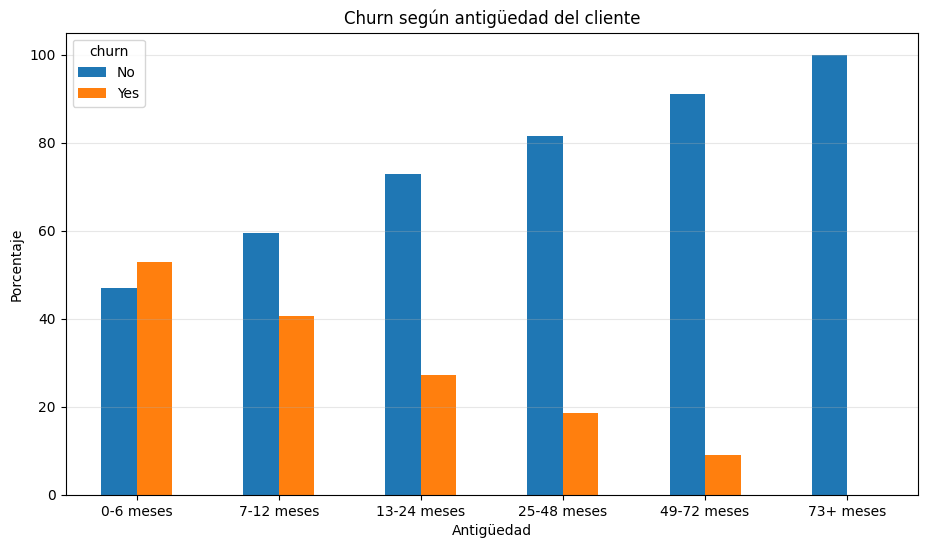

In [ ]:
churn_tenure.plot(
    kind='bar',
    figsize=(11,6)
)

plt.title('Churn según antigüedad del cliente')
plt.xlabel('Antigüedad')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

Se verá una tendencia muy clara: los clientes más recientes presentan mayores niveles de abandono

In [ ]:
resumen = pd.DataFrame({
    'Indicador': [
        'Clientes totales',
        'Variables',
        'Clientes que abandonaron',
        'Tasa general de Churn',
        'Faltantes originales',
        'Faltantes después de limpieza',
        'Duplicados originales',
        'Duplicados después de limpieza'
    ],
    'Resultado': [
        len(df_limpio),
        df_limpio.shape[1],
        (df_limpio['churn'] == 'Yes').sum(),
        round((df_limpio['churn'] == 'Yes').mean()*100, 2),
        df_crudo.isnull().sum().sum(),
        df_limpio.isnull().sum().sum(),
        df_crudo.duplicated().sum(),
        df_limpio.duplicated().sum()
    ]
})

resumen

,Indicador,Resultado
0,Clientes totales,7043.00
1,Variables,22.00
2,Clientes que abandonaron,1869.00
3,Tasa general de Churn,26.54
4,Faltantes originales,8250.00
5,Faltantes después de limpieza,0.00
6,Duplicados originales,0.00
7,Duplicados después de limpieza,0.00


In [ ]:
print("Clientes disponibles para analizar tenure en la base original:")
print(df_crudo['tenure'].notna().sum())

print("\nClientes disponibles después de la limpieza:")
print(df_limpio['tenure'].notna().sum())


Clientes disponibles para analizar tenure en la base original:
4543

Clientes disponibles después de la limpieza:
7043


In [ ]:
print(
    "Porcentaje de clientes disponibles para analizar simultáneamente "
    "las variables afectadas:"
)

variables_afectadas = [
    'gender',
    'partner',
    'tenure',
    'internetservice',
    'streamingtv',
    'monthlycharges'
]

completos = df_crudo[variables_afectadas].notna().all(axis=1).sum()

print(completos)
print(round(completos / len(df_crudo) * 100, 2), "%")

Porcentaje de clientes disponibles para analizar simultáneamente las variables afectadas:
4543
64.5 %


Si se hubiera trabajado directamente con los datos crudos y se hubiera exigido información completa para las variables afectadas, el análisis habría utilizado solamente alrededor del 64,5 % de los clientes. La limpieza permitió conservar los 7.043 registros, evitando una pérdida importante de información.

In [ ]:
# ============================================
# DIAPOSITIVA 11
# Resumen: datos crudos vs. datos limpios
# ============================================

tabla_resumen = pd.DataFrame({
    'Aspecto': [
        'Registros',
        'Variables originales',
        'Valores faltantes',
        'Registros duplicados',
        'TotalCharges',
        'Variables categóricas',
        'Tenure',
        'MonthlyCharges'
    ],

    'Base original': [
        df_crudo.shape[0],
        21,
        df_crudo.isnull().sum().sum(),
        df_crudo.duplicated().sum(),
        'Problemas de formato',
        'Valores NaN',
        '2.500 faltantes',
        '1.500 faltantes'
    ],

    'Base limpia': [
        df_limpio.shape[0],
        21,
        df_limpio.isnull().sum().sum(),
        df_limpio.duplicated().sum(),
        'Tratado como numérico',
        '"No registrado"',
        'Valores tratados',
        'Valores tratados'
    ]
})

tabla_resumen

,Aspecto,Base original,Base limpia
0,Registros,7043,7043
1,Variables originales,21,21
2,Valores faltantes,8250,0
3,Registros duplicados,0,0
4,TotalCharges,Problemas de formato,Tratado como numérico
5,Variables categóricas,Valores NaN,"""No registrado"""
6,Tenure,2.500 faltantes,Valores tratados
7,MonthlyCharges,1.500 faltantes,Valores tratados


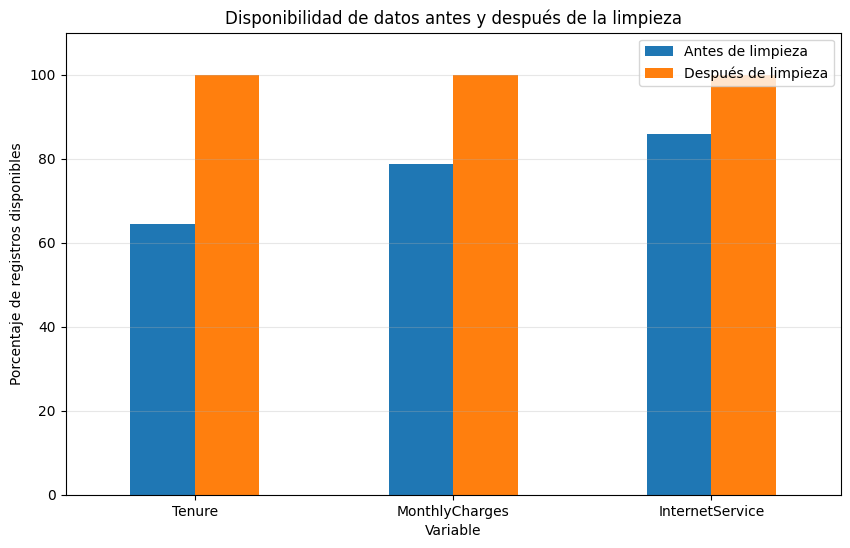

In [ ]:
disponibilidad = pd.DataFrame({
    'Antes de limpieza': [
        df_crudo['tenure'].notna().mean() * 100,
        df_crudo['monthlycharges'].notna().mean() * 100,
        df_crudo['internetservice'].notna().mean() * 100
    ],
    'Después de limpieza': [
        df_limpio['tenure'].notna().mean() * 100,
        df_limpio['monthlycharges'].notna().mean() * 100,
        df_limpio['internetservice'].notna().mean() * 100
    ]
}, index=[
    'Tenure',
    'MonthlyCharges',
    'InternetService'
])

disponibilidad.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Disponibilidad de datos antes y después de la limpieza')
plt.ylabel('Porcentaje de registros disponibles')
plt.xlabel('Variable')
plt.xticks(rotation=0)
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
"Tamaño de bases"

print("BASE ORIGINAL")
print("Filas:", df_crudo.shape[0])
print("Columnas:", df_crudo.shape[1])

print("\nBASE LIMPIA")
print("Filas:", df_limpio.shape[0])
print("Columnas:", df_limpio.shape[1])

"""La limpieza no eliminó registros ni variables; el objetivo fue
mejorar la calidad y consistencia de los datos conservando la
totalidad de la información disponible."""

BASE ORIGINAL
Filas: 7043
Columnas: 21

BASE LIMPIA
Filas: 7043
Columnas: 22


'La limpieza no eliminó registros ni variables; el objetivo fue\nmejorar la calidad y consistencia de los datos conservando la\ntotalidad de la información disponible.'

In [ ]:
# Tabla comparativa de las bases de datos

tabla_datos = pd.DataFrame({
    'Característica': [
        'Registros',
        'Variables originales',
        'Valores faltantes',
        'Registros duplicados'
    ],

    'Base original': [
        df_crudo.shape[0],
        21,
        df_crudo.isnull().sum().sum(),
        df_crudo.duplicated().sum()
    ],

    'Base limpia': [
        df_limpio.shape[0],
        21,
        df_limpio.isnull().sum().sum(),
        df_limpio.duplicated().sum()
    ]
})

tabla_datos

,Característica,Base original,Base limpia
0,Registros,7043,7043
1,Variables originales,21,21
2,Valores faltantes,8250,0
3,Registros duplicados,0,0


In [ ]:
"Cinco primeras filas del dataframe original"
df_crudo.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
"Cinco primeras filas del dataframe limpio "
df_limpio.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,grupo_tenure
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-6 meses
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48 meses
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-6 meses
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 meses
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-6 meses


In [ ]:
"Tabla mostrando variables que tenian valores faltantes, cuantos y que porcentaje"

faltantes = pd.DataFrame({
    'Cantidad': df_crudo.isnull().sum(),
    'Porcentaje': df_crudo.isnull().mean() * 100
})

faltantes = faltantes[faltantes['Cantidad'] > 0]
faltantes = faltantes.sort_values('Cantidad', ascending=False)

faltantes

,Cantidad,Porcentaje
tenure,2500,35.496237
streamingtv,1500,21.297742
monthlycharges,1500,21.297742
partner,1000,14.198495
internetservice,1000,14.198495
gender,750,10.648871


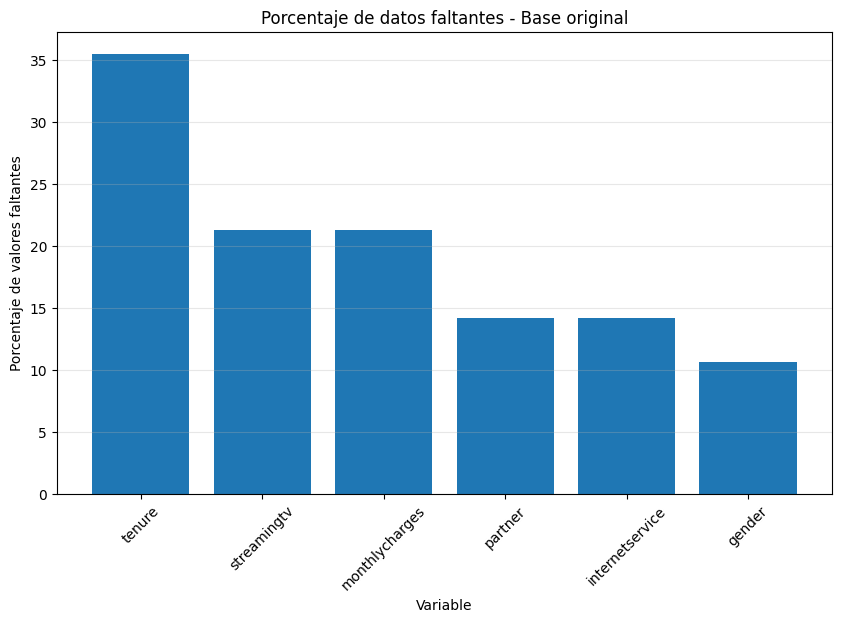

'Antes de realizar cualquier análisis exploratorio fue necesario\nevaluar la calidad de los datos. Se identificó que algunas variables\npresentaban una proporción considerable de valores faltantes.\nEl caso más crítico fue tenure (cantidad de meses que el cliente\nlleva siendo cliente de la empresa), donde aproximadamente el 35,5 %\nde los registros no tenía información. Trabajar directamente con\nestos datos habría reducido considerablemente la cantidad de observaciones\ndisponibles para determinados análisis.'

In [ ]:
"Grafica de barras donde aparece la varible con mayor cantidad de datos faltantes"

plt.figure(figsize=(10,6))

plt.bar(faltantes.index, faltantes['Porcentaje'])

plt.title('Porcentaje de datos faltantes - Base original')
plt.xlabel('Variable')
plt.ylabel('Porcentaje de valores faltantes')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

"""Antes de realizar cualquier análisis exploratorio fue necesario
evaluar la calidad de los datos. Se identificó que algunas variables
presentaban una proporción considerable de valores faltantes.
El caso más crítico fue tenure (cantidad de meses que el cliente
lleva siendo cliente de la empresa), donde aproximadamente el 35,5 %
de los registros no tenía información. Trabajar directamente con
estos datos habría reducido considerablemente la cantidad de observaciones
disponibles para determinados análisis."""

In [ ]:
"""En esta tabla comparamos la cantidad de valores faltantes antes
y después del proceso de limpieza. En la base original encontramos
problemas especialmente importantes en variables como tenure, que
presentaba 2.500 registros sin información, y streamingtv y monthlycharges,
con 1.500 registros faltantes cada una. Después del proceso de limpieza,
estas variables pasan a tener cero valores faltantes. Esto demuestra que
el proceso permitió aumentar la disponibilidad de información sin
eliminar los registros de la base"""

comparacion_faltantes = pd.DataFrame({
    'Original': df_crudo.isnull().sum(),
    'Limpia': df_limpio.isnull().sum()
})

comparacion_faltantes = comparacion_faltantes[
    (comparacion_faltantes['Original'] > 0) |
    (comparacion_faltantes['Limpia'] > 0)
]

comparacion_faltantes



,Original,Limpia
gender,750.0,0
internetservice,1000.0,0
monthlycharges,1500.0,0
partner,1000.0,0
streamingtv,1500.0,0
tenure,2500.0,0


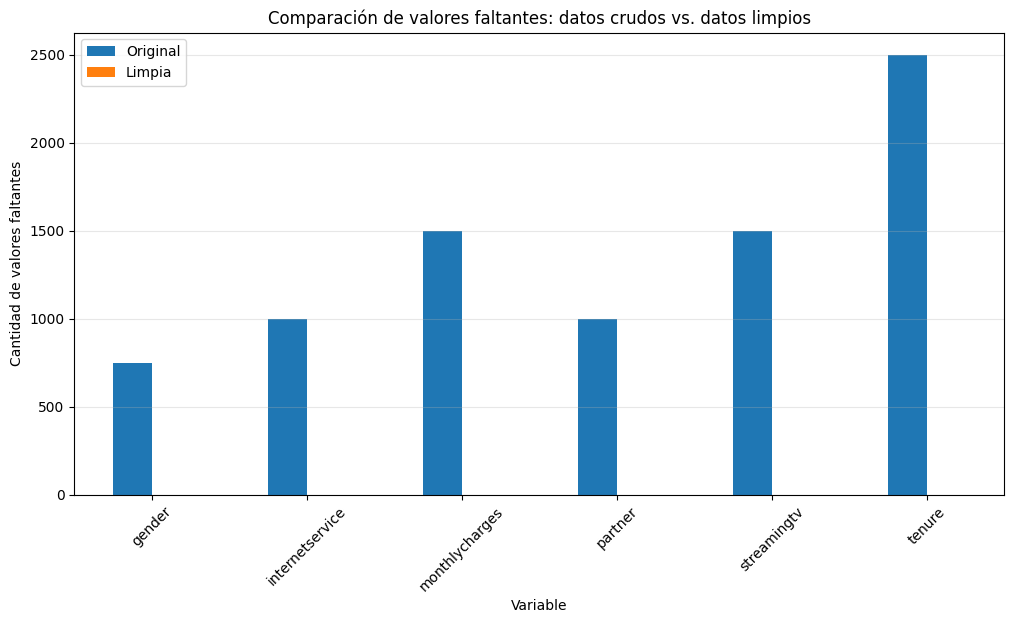

In [ ]:
comparacion_faltantes.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Comparación de valores faltantes: datos crudos vs. datos limpios')
plt.xlabel('Variable')
plt.ylabel('Cantidad de valores faltantes')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()



In [ ]:
print("GENDER ORIGINAL")
print(df_crudo['gender'].value_counts(dropna=False))

print("\nGENDER LIMPIO")
print(df_limpio['gender'].value_counts(dropna=False))

GENDER ORIGINAL
gender
Male      3202
Female    3091
NaN        750
Name: count, dtype: int64

GENDER LIMPIO
gender
Male             3202
Female           3091
No registrado     750
Name: count, dtype: int64


In [ ]:
"""Se optienen todos los nombres de las columnas"""

df_crudo.columns = (
    df_crudo.columns
    .str.strip()
    .str.lower()
)

df_limpio.columns = (
    df_limpio.columns
    .str.strip()
    .str.lower()
)

print("Columnas de la BASE ORIGINAL:")
print(df_crudo.columns.tolist())

print("\nColumnas de la BASE LIMPIA:")
print(df_limpio.columns.tolist())

Columnas de la BASE ORIGINAL:
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']

Columnas de la BASE LIMPIA:
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn', 'grupo_tenure']


In [ ]:
variables_categoricas = [
    'gender',
    'partner',
    'internetservice',
    'streamingtv'
]

for variable in variables_categoricas:

    print("\n" + "="*50)
    print(variable.upper())
    print("="*50)

    print("\nORIGINAL:")
    print(df_crudo[variable].value_counts(dropna=False))

    print("\nLIMPIA:")
    print(df_limpio[variable].value_counts(dropna=False))


GENDER

ORIGINAL:
gender
Male      3202
Female    3091
NaN        750
Name: count, dtype: int64

LIMPIA:
gender
Male             3202
Female           3091
No registrado     750
Name: count, dtype: int64

PARTNER

ORIGINAL:
partner
No     3115
Yes    2928
NaN    1000
Name: count, dtype: int64

LIMPIA:
partner
No               3115
Yes              2928
No registrado    1000
Name: count, dtype: int64

INTERNETSERVICE

ORIGINAL:
internetservice
Fiber optic    2660
DSL            2082
No             1301
NaN            1000
Name: count, dtype: int64

LIMPIA:
internetservice
Fiber optic      2660
DSL              2082
No               1301
No registrado    1000
Name: count, dtype: int64

STREAMINGTV

ORIGINAL:
streamingtv
No                     2199
Yes                    2146
NaN                    1500
No internet service    1198
Name: count, dtype: int64

LIMPIA:
streamingtv
No                     2199
Yes                    2146
No registrado          1500
No internet service    1198


In [ ]:
print(df_crudo['totalcharges'].dtype)

object


In [ ]:
print(df_limpio['totalcharges'].dtype)

float64


In [ ]:
"""Regitros donde el numero no podia interpretarse correctamente"""

totalcharges_numerico = pd.to_numeric(
    df_crudo['totalcharges'],
    errors='coerce'
)

problemas_totalcharges = df_crudo[
    totalcharges_numerico.isna()
]

problemas_totalcharges[['customerid', 'tenure', 'totalcharges']]

,customerid,tenure,totalcharges
488,4472-LVYGI,0.0,
753,3115-CZMZD,0.0,
936,5709-LVOEQ,0.0,
1082,4367-NUYAO,0.0,
1340,1371-DWPAZ,NaN,
3331,7644-OMVMY,0.0,
3826,3213-VVOLG,0.0,
4380,2520-SGTTA,0.0,
5218,2923-ARZLG,0.0,
6670,4075-WKNIU,NaN,


In [ ]:
print("NaN en TotalCharges - ORIGINAL:")
print(df_crudo['totalcharges'].isna().sum())

print("\nNaN en TotalCharges - LIMPIA:")
print(df_limpio['totalcharges'].isna().sum())

NaN en TotalCharges - ORIGINAL:
0

NaN en TotalCharges - LIMPIA:
0


In [ ]:
"""Muestra los registros que no podian convertirse en numericos"""
df_limpio.loc[
    totalcharges_numerico.isna(),
    ['customerid', 'tenure', 'totalcharges']
]

,customerid,tenure,totalcharges
488,4472-LVYGI,0.0,0.0
753,3115-CZMZD,0.0,0.0
936,5709-LVOEQ,0.0,0.0
1082,4367-NUYAO,0.0,0.0
1340,1371-DWPAZ,64.0,3587.2
3331,7644-OMVMY,0.0,0.0
3826,3213-VVOLG,0.0,0.0
4380,2520-SGTTA,0.0,0.0
5218,2923-ARZLG,0.0,0.0
6670,4075-WKNIU,64.0,4499.2


Estos clientes tienen 64 meses de antigüedad, pero originalmente totalcharges no tenía un valor interpretable.

Eso significa que el proceso de limpieza tuvo que tomar una decisión sobre qué hacer con esos datos faltantes.

Se identificaron 11 registros cuyo valor de TotalCharges no podía interpretarse como numérico. Durante la limpieza estos valores fueron tratados y convertidos a valores numéricos, pero el tratamiento debe considerarse al interpretar posteriormente esta variable, ya que convertir un valor faltante en 0 implica asumir que no existía un cargo registrado."

In [ ]:
print("Original:")
print(df_crudo['monthlycharges'].describe())

print("\nLimpia:")
print(df_limpio['monthlycharges'].describe())

Original:
count    5543.000000
mean       64.876403
std        30.101331
min        18.250000
25%        35.750000
50%        70.550000
75%        89.925000
max       118.600000
Name: monthlycharges, dtype: float64

Limpia:
count    7043.000000
mean       65.594455
std        27.758845
min        18.250000
25%        45.750000
50%        70.300000
75%        87.850000
max       118.600000
Name: monthlycharges, dtype: float64


In [ ]:
mask = df_crudo['monthlycharges'].isna()

comparacion_monthly = pd.DataFrame({
    'internetservice': df_limpio.loc[mask, 'internetservice'],
    'monthlycharges_asignado': df_limpio.loc[mask, 'monthlycharges']
})

comparacion_monthly.groupby(
    ['internetservice', 'monthlycharges_asignado']
).size().reset_index(name='cantidad')

,internetservice,monthlycharges_asignado,cantidad
0,DSL,56.075,182
1,Fiber optic,92.050,215
2,No,20.150,103
3,No registrado,70.300,1000


En esta gráfica analizamos específicamente los 1.500 registros que originalmente no tenían información en MonthlyCharges. Observamos que la mayor parte, 1.000 registros, corresponde a clientes cuyo servicio de Internet tampoco estaba registrado. Los restantes valores se distribuyeron entre DSL, fibra óptica y clientes sin servicio de Internet. Esto nos permitió conservar estos registros para el análisis, aunque debemos tener en cuenta que los valores imputados no corresponden necesariamente al valor real que tenía cada cliente.

In [ ]:
print("Mediana de tenure por tipo de contrato:")
print(df_crudo.groupby('contract')['tenure'].median())

Mediana de tenure por tipo de contrato:
contract
Month-to-month    12.0
One year          43.0
Two year          64.0
Name: tenure, dtype: float64


Month-to-month → 12 meses

One year → 43 meses

Two year → 64 meses

In [ ]:
mask = df_crudo['tenure'].isna()

df_tenure = pd.DataFrame({
    'contract': df_crudo.loc[mask, 'contract'],
    'tenure_imputado': df_limpio.loc[mask, 'tenure']
})

df_tenure.groupby(
    ['contract', 'tenure_imputado']
).size().reset_index(name='cantidad').sort_values(
    ['contract', 'cantidad'],
    ascending=[True, False]
).head(30)

,contract,tenure_imputado,cantidad
11,Month-to-month,12.0,848
0,Month-to-month,1.0,87
1,Month-to-month,2.0,28
2,Month-to-month,3.0,26
3,Month-to-month,4.0,24
6,Month-to-month,7.0,24
4,Month-to-month,5.0,18
7,Month-to-month,8.0,14
8,Month-to-month,9.0,14
16,Month-to-month,17.0,13


tenure = cantidad de meses que el cliente lleva con la empresa.

Por ejemplo, tenure = 12 significa que lleva 12 meses, es decir, aproximadamente un año.

Tenure fue una de las variables con mayor cantidad de datos faltantes, con 2.500 registros. Para analizar cómo fueron tratados, relacionamos los valores imputados con el tipo de contrato del cliente. Encontramos que para los clientes con contrato mensual el valor de 12 meses fue el más frecuente, con 848 registros. Esto es consistente con el uso de una medida de tendencia central, como la mediana del grupo, para realizar la imputación. De esta manera, no se utilizó necesariamente un único valor para todos los clientes, sino que se tuvo en cuenta información disponible en otras variables."

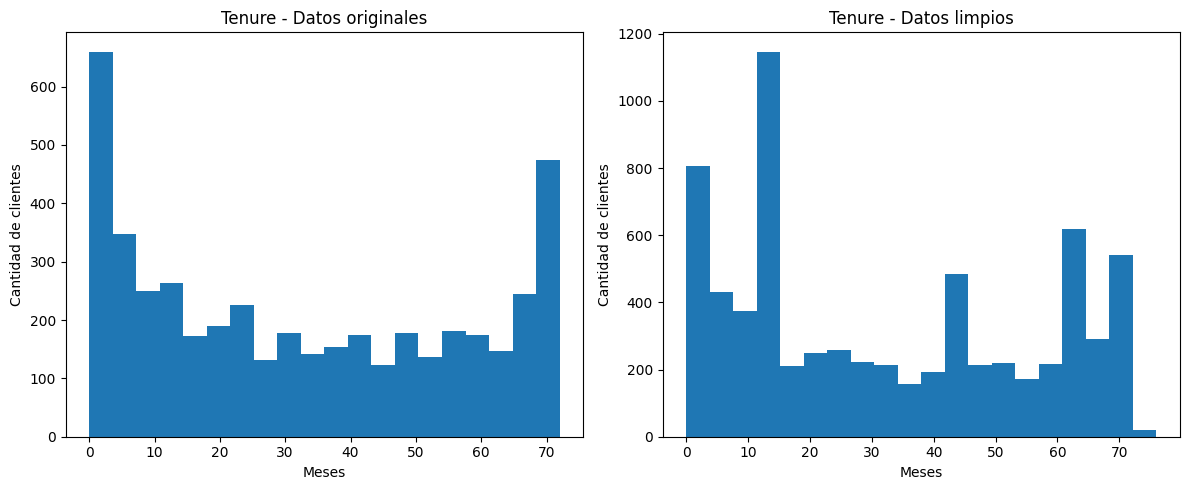

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df_crudo['tenure'].dropna(), bins=20)
plt.title('Tenure - Datos originales')
plt.xlabel('Meses')
plt.ylabel('Cantidad de clientes')

plt.subplot(1,2,2)
plt.hist(df_limpio['tenure'], bins=20)
plt.title('Tenure - Datos limpios')
plt.xlabel('Meses')
plt.ylabel('Cantidad de clientes')

plt.tight_layout()
plt.show()

La limpieza permitió trabajar con el 100 % de los registros para esta variable, pero también modificó su distribución. Por esta razón, la imputación no debe verse únicamente como una forma de eliminar valores vacíos, sino como una decisión que puede tener efectos sobre los resultados posteriores.

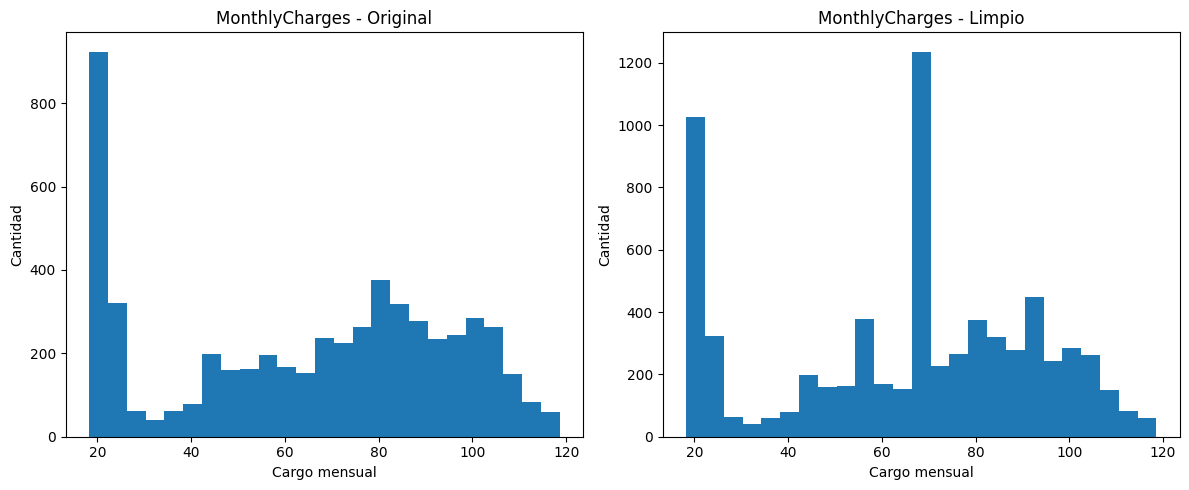

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df_crudo['monthlycharges'].dropna(), bins=25)
plt.title('MonthlyCharges - Original')
plt.xlabel('Cargo mensual')
plt.ylabel('Cantidad')

plt.subplot(1,2,2)
plt.hist(df_limpio['monthlycharges'], bins=25)
plt.title('MonthlyCharges - Limpio')
plt.xlabel('Cargo mensual')
plt.ylabel('Cantidad')

plt.tight_layout()
plt.show()

En esta comparación observamos la distribución de MonthlyCharges antes y después de la limpieza. En la base original existían 1.500 valores faltantes, por lo que el primer histograma solamente representa los registros que tenían información disponible. Después de la limpieza se incorporaron los valores tratados, aumentando la cantidad de información disponible. Sin embargo, podemos observar que aparecen concentraciones más marcadas alrededor de determinados valores. Esto se debe al proceso de imputación, que asignó valores específicos a los registros faltantes. Por lo tanto, la limpieza permitió completar la base, pero también modificó parcialmente la distribución de la variable, algo que debemos considerar al interpretar los resultados.

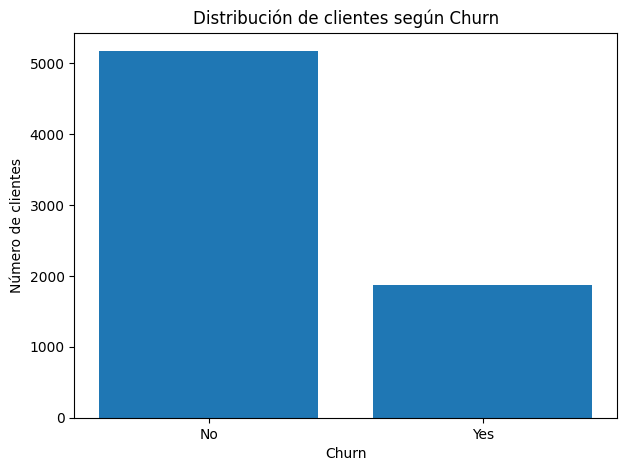

churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentajes:
churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
churn = df_limpio['churn'].value_counts()

plt.figure(figsize=(7,5))

plt.bar(churn.index, churn.values)

plt.title('Distribución de clientes según Churn')
plt.xlabel('Churn')
plt.ylabel('Número de clientes')

plt.show()

print(churn)
print("\nPorcentajes:")
print(df_limpio['churn'].value_counts(normalize=True) * 100)

In [ ]:
tabla_contrato = pd.crosstab(
    df_limpio['contract'],
    df_limpio['churn'],
    normalize='index'
) * 100

tabla_contrato

churn,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


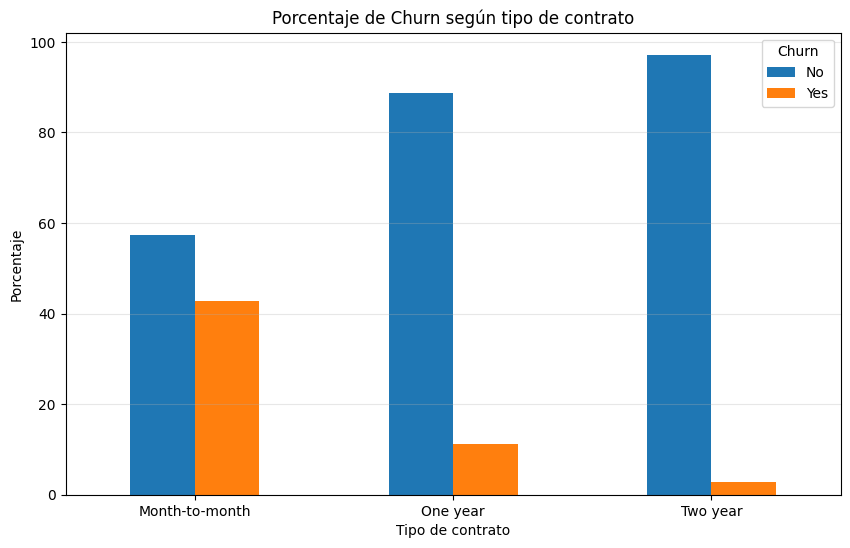

In [ ]:
tabla_contrato.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Porcentaje de Churn según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.grid(axis='y', alpha=0.3)

plt.show()

Se observa una relación clara entre la duración del contrato y la permanencia del cliente. Los usuarios con contratos mes a mes presentan una tasa de abandono considerablemente mayor que aquellos con contratos de uno o dos años.

In [ ]:
tabla_internet = pd.crosstab(
    df_limpio['internetservice'],
    df_limpio['churn'],
    normalize='index'
) * 100

tabla_internet

churn,No,Yes
internetservice,,
DSL,80.739673,19.260327
Fiber optic,58.496241,41.503759
No,92.390469,7.609531
No registrado,73.500000,26.500000


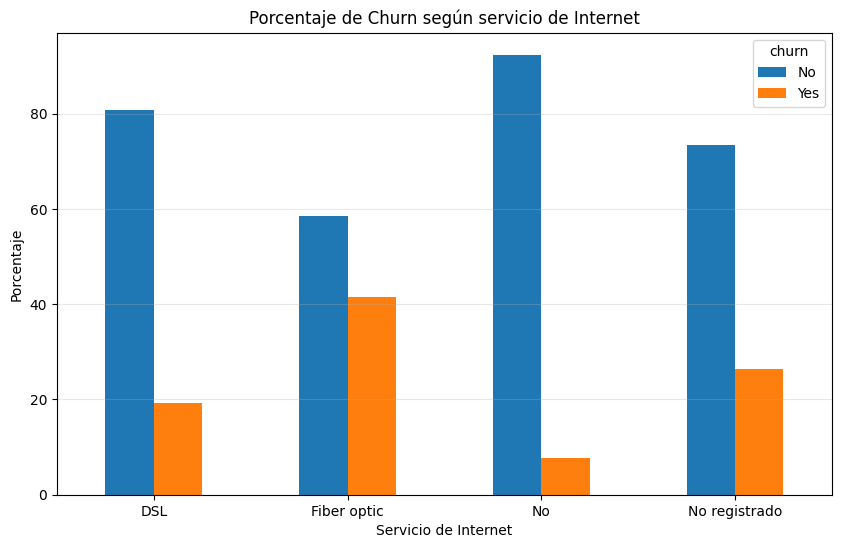

In [ ]:
tabla_internet.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Porcentaje de Churn según servicio de Internet')
plt.xlabel('Servicio de Internet')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
"""Clasificacion de clientes segun antiguedad: Nueva variable"""

bins = [-1, 6, 12, 24, 48, 72, 100]

labels = [
    '0-6 meses',
    '7-12 meses',
    '13-24 meses',
    '25-48 meses',
    '49-72 meses',
    '73+ meses'
]

df_limpio['grupo_tenure'] = pd.cut(
    df_limpio['tenure'],
    bins=bins,
    labels=labels
)

In [ ]:
churn_tenure = pd.crosstab(
    df_limpio['grupo_tenure'],
    df_limpio['churn'],
    normalize='index'
) * 100

churn_tenure

churn,No,Yes
grupo_tenure,,
0-6 meses,47.007042,52.992958
7-12 meses,59.375000,40.625000
13-24 meses,72.875000,27.125000
25-48 meses,81.533546,18.466454
49-72 meses,91.059603,8.940397
73+ meses,100.000000,0.000000


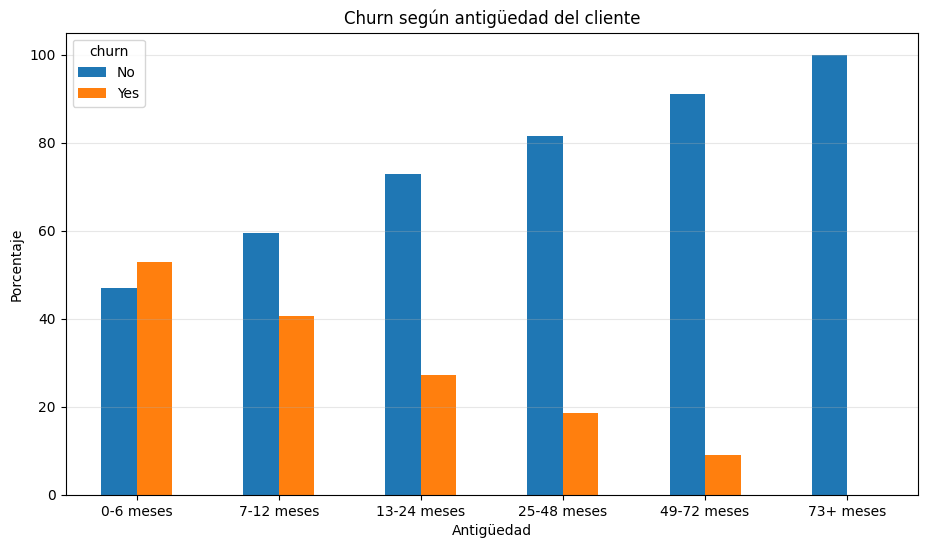

In [ ]:
churn_tenure.plot(
    kind='bar',
    figsize=(11,6)
)

plt.title('Churn según antigüedad del cliente')
plt.xlabel('Antigüedad')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

Se verá una tendencia muy clara: los clientes más recientes presentan mayores niveles de abandono

In [ ]:
resumen = pd.DataFrame({
    'Indicador': [
        'Clientes totales',
        'Variables',
        'Clientes que abandonaron',
        'Tasa general de Churn',
        'Faltantes originales',
        'Faltantes después de limpieza',
        'Duplicados originales',
        'Duplicados después de limpieza'
    ],
    'Resultado': [
        len(df_limpio),
        df_limpio.shape[1],
        (df_limpio['churn'] == 'Yes').sum(),
        round((df_limpio['churn'] == 'Yes').mean()*100, 2),
        df_crudo.isnull().sum().sum(),
        df_limpio.isnull().sum().sum(),
        df_crudo.duplicated().sum(),
        df_limpio.duplicated().sum()
    ]
})

resumen

,Indicador,Resultado
0,Clientes totales,7043.00
1,Variables,22.00
2,Clientes que abandonaron,1869.00
3,Tasa general de Churn,26.54
4,Faltantes originales,8250.00
5,Faltantes después de limpieza,0.00
6,Duplicados originales,0.00
7,Duplicados después de limpieza,0.00


In [ ]:
print("Clientes disponibles para analizar tenure en la base original:")
print(df_crudo['tenure'].notna().sum())

print("\nClientes disponibles después de la limpieza:")
print(df_limpio['tenure'].notna().sum())


Clientes disponibles para analizar tenure en la base original:
4543

Clientes disponibles después de la limpieza:
7043


In [ ]:
print(
    "Porcentaje de clientes disponibles para analizar simultáneamente "
    "las variables afectadas:"
)

variables_afectadas = [
    'gender',
    'partner',
    'tenure',
    'internetservice',
    'streamingtv',
    'monthlycharges'
]

completos = df_crudo[variables_afectadas].notna().all(axis=1).sum()

print(completos)
print(round(completos / len(df_crudo) * 100, 2), "%")

Porcentaje de clientes disponibles para analizar simultáneamente las variables afectadas:
4543
64.5 %


Si se hubiera trabajado directamente con los datos crudos y se hubiera exigido información completa para las variables afectadas, el análisis habría utilizado solamente alrededor del 64,5 % de los clientes. La limpieza permitió conservar los 7.043 registros, evitando una pérdida importante de información.

In [ ]:
# ============================================
# DIAPOSITIVA 11
# Resumen: datos crudos vs. datos limpios
# ============================================

tabla_resumen = pd.DataFrame({
    'Aspecto': [
        'Registros',
        'Variables originales',
        'Valores faltantes',
        'Registros duplicados',
        'TotalCharges',
        'Variables categóricas',
        'Tenure',
        'MonthlyCharges'
    ],

    'Base original': [
        df_crudo.shape[0],
        21,
        df_crudo.isnull().sum().sum(),
        df_crudo.duplicated().sum(),
        'Problemas de formato',
        'Valores NaN',
        '2.500 faltantes',
        '1.500 faltantes'
    ],

    'Base limpia': [
        df_limpio.shape[0],
        21,
        df_limpio.isnull().sum().sum(),
        df_limpio.duplicated().sum(),
        'Tratado como numérico',
        '"No registrado"',
        'Valores tratados',
        'Valores tratados'
    ]
})

tabla_resumen

,Aspecto,Base original,Base limpia
0,Registros,7043,7043
1,Variables originales,21,21
2,Valores faltantes,8250,0
3,Registros duplicados,0,0
4,TotalCharges,Problemas de formato,Tratado como numérico
5,Variables categóricas,Valores NaN,"""No registrado"""
6,Tenure,2.500 faltantes,Valores tratados
7,MonthlyCharges,1.500 faltantes,Valores tratados


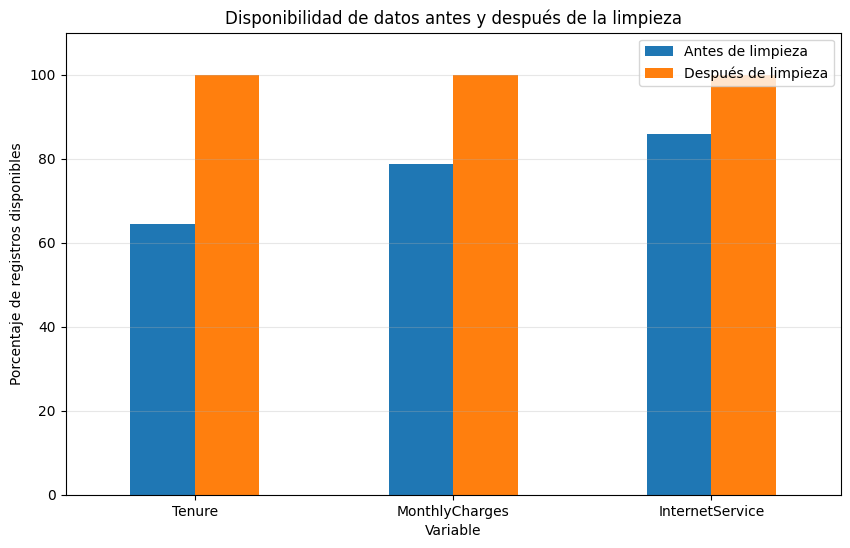

In [ ]:
disponibilidad = pd.DataFrame({
    'Antes de limpieza': [
        df_crudo['tenure'].notna().mean() * 100,
        df_crudo['monthlycharges'].notna().mean() * 100,
        df_crudo['internetservice'].notna().mean() * 100
    ],
    'Después de limpieza': [
        df_limpio['tenure'].notna().mean() * 100,
        df_limpio['monthlycharges'].notna().mean() * 100,
        df_limpio['internetservice'].notna().mean() * 100
    ]
}, index=[
    'Tenure',
    'MonthlyCharges',
    'InternetService'
])

disponibilidad.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Disponibilidad de datos antes y después de la limpieza')
plt.ylabel('Porcentaje de registros disponibles')
plt.xlabel('Variable')
plt.xticks(rotation=0)
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3)

plt.show()

## Modelado predictivo

In [ ]:
# ============================================================
# SELECCION DE MODELOS Y JUSTIFICACION
# ============================================================
# El problema es de clasificacion binaria: predecir si un cliente
# se va (churn = Yes) o se queda (churn = No). Se entrenan dos
# modelos distintos, no para combinarlos, sino para compararlos
# entre si con las mismas metricas y quedarnos con el que mejor
# se desempeñe:
#
# 1)Regresion logistica: modelo lineal, rapido de entrenar y
#   facil de interpretar. Sirve como punto de referencia
#   para saber si vale la pena algo mas complejo.
#
# 2)Random Forest: suma muchos arboles de decision
#   lo que le permite capturar relaciones no lineales entre
#   variables, como las que ya se ven en el EDA (contrato,
#   servicio de internet y metodo de pago no se comportan de
#   forma lineal frente al churn).
#
# Se entrenan los dos sobre los mismos datos de entrenamiento y
# se evaluan sobre el mismo conjunto de prueba, para que la
# comparacion sea justa. Al final se elige un solo modelo ganador
# segun las metricas, no se usan los dos combinados.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [ ]:
# PREPARACION DE DATOS PARA MODELAR
# Se parte de df_limpio
# sin modificar nada de lo que ya se hizo.

df_modelo = df_limpio.copy()

# Variable objetivo: 1 si el cliente se fue Yes, 0 si se quedo No
df_modelo["churn_bin"] = (df_modelo["churn"] == "Yes").astype(int)

# Se quitan columnas que no sirven como predictoras
columnas_excluir = ["customerid", "churn", "churn_bin", "grupo_tenure"]
X = df_modelo.drop(columns=[c for c in columnas_excluir if c in df_modelo.columns])
y = df_modelo["churn_bin"]

# Las variables categoricas se convierten a variables dummy (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)

# Division train/test (80/20), estratificada porque las clases estan desbalanceadas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamano de entrenamiento:", X_train.shape)
print("Tamano de prueba       :", X_test.shape)
print("Proporcion de churn en train:", round(y_train.mean(), 3))
print("Proporcion de churn en test :", round(y_test.mean(), 3))

Tamano de entrenamiento: (5634, 34)
Tamano de prueba       : (1409, 34)
Proporcion de churn en train: 0.265
Proporcion de churn en test : 0.265


In [ ]:
# ------------------------------------------------------------
# APLICACION - MODELO 1: REGRESION LOGISTICA
# ------------------------------------------------------------
# Este modelo si necesita las variables en escalas comparables,
# por eso se estandarizan antes de entrenar.
escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)
X_test_esc = escalador.transform(X_test)

modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)
modelo_logistico.fit(X_train_esc, y_train)

pred_log = modelo_logistico.predict(X_test_esc)
proba_log = modelo_logistico.predict_proba(X_test_esc)[:, 1]

print("Regresion logistica entrenada.")

Regresion logistica entrenada.


In [ ]:
# ------------------------------------------------------------
# APLICACION - MODELO 2: RANDOM FOREST
# ------------------------------------------------------------
# Random Forest no necesita estandarizacion, se entrena directo
# sobre las variables originales
modelo_bosque = RandomForestClassifier(
    n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
)
modelo_bosque.fit(X_train, y_train)

pred_bosque = modelo_bosque.predict(X_test)
proba_bosque = modelo_bosque.predict_proba(X_test)[:, 1]

print("Random Forest entrenado.")

Random Forest entrenado.


In [ ]:
# ------------------------------------------------------------
# EVALUACION DE LOS MODELOS
# ------------------------------------------------------------
def evaluar(nombre, y_real, y_pred, y_proba):
    print(f"--- {nombre} ---")
    print(f"Accuracy : {accuracy_score(y_real, y_pred):.3f}")
    print(f"Precision: {precision_score(y_real, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_real, y_pred):.3f}")
    print(f"F1-score : {f1_score(y_real, y_pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_real, y_proba):.3f}")
    print("\nMatriz de confusion (filas=real, columnas=prediccion):")
    print(confusion_matrix(y_real, y_pred))
    print("\nReporte completo:")
    print(classification_report(y_real, y_pred, target_names=["No se va", "Se va"]))
    print()

evaluar("Regresion logistica", y_test, pred_log, proba_log)
evaluar("Random Forest", y_test, pred_bosque, proba_bosque)

--- Regresion logistica ---
Accuracy : 0.786
Precision: 0.618
Recall   : 0.505
F1-score : 0.556
ROC-AUC  : 0.831

Matriz de confusion (filas=real, columnas=prediccion):
[[918 117]
 [185 189]]

Reporte completo:
              precision    recall  f1-score   support

    No se va       0.83      0.89      0.86      1035
       Se va       0.62      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


--- Random Forest ---
Accuracy : 0.795
Precision: 0.637
Recall   : 0.529
F1-score : 0.578
ROC-AUC  : 0.827

Matriz de confusion (filas=real, columnas=prediccion):
[[922 113]
 [176 198]]

Reporte completo:
              precision    recall  f1-score   support

    No se va       0.84      0.89      0.86      1035
       Se va       0.64      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71     

In [ ]:
# ------------------------------------------------------------
# COMPARACION DIRECTA Y ELECCION DEL MEJOR MODELO
# ------------------------------------------------------------
# Se arma una tabla lado a lado con las mismas metricas para los
# dos modelos, y se elige un unico ganador. El criterio de
# desempate es el F1-score de la clase churn, porque en este
# problema interesa tanto detectar a los clientes que se van
# (recall) como no gastar recursos contactando a quien no se iba
# a ir (precision), y el F1 balancea ambas cosas.

comparacion = pd.DataFrame({
    "Regresion logistica": {
        "Accuracy": accuracy_score(y_test, pred_log),
        "Precision": precision_score(y_test, pred_log),
        "Recall": recall_score(y_test, pred_log),
        "F1-score": f1_score(y_test, pred_log),
        "ROC-AUC": roc_auc_score(y_test, proba_log),
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, pred_bosque),
        "Precision": precision_score(y_test, pred_bosque),
        "Recall": recall_score(y_test, pred_bosque),
        "F1-score": f1_score(y_test, pred_bosque),
        "ROC-AUC": roc_auc_score(y_test, proba_bosque),
    },
}).round(3)

print(comparacion)

f1_log = f1_score(y_test, pred_log)
f1_bosque = f1_score(y_test, pred_bosque)

if f1_bosque > f1_log:
    modelo_ganador = "Random Forest"
else:
    modelo_ganador = "Regresion logistica"

print(f"\nModelo ganador segun F1-score: {modelo_ganador}")

           Regresion logistica  Random Forest
Accuracy                 0.786          0.795
Precision                0.618          0.637
Recall                   0.505          0.529
F1-score                 0.556          0.578
ROC-AUC                  0.831          0.827

Modelo ganador segun F1-score: Random Forest


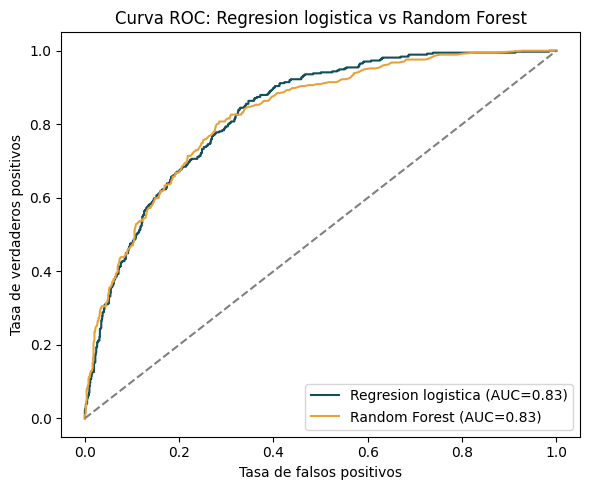

In [ ]:
# Comparacion visual: curvas ROC de los dos modelos
fpr_log, tpr_log, _ = roc_curve(y_test, proba_log)
fpr_bosque, tpr_bosque, _ = roc_curve(y_test, proba_bosque)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f"Regresion logistica (AUC={roc_auc_score(y_test, proba_log):.2f})", color="#124F5A")
plt.plot(fpr_bosque, tpr_bosque, label=f"Random Forest (AUC={roc_auc_score(y_test, proba_bosque):.2f})", color="#E9A23B")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC: Regresion logistica vs Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# INTERPRETACION DE RESULTADOS Y CONCLUSION
# ------------------------------------------------------------
# Que variables pesan mas en cada modelo.
coef_log = pd.Series(modelo_logistico.coef_[0], index=X.columns).sort_values()
print("Variables que mas AUMENTAN la probabilidad de churn (regresion logistica):")
print(coef_log.tail(5))
print("\nVariables que mas REDUCEN la probabilidad de churn (regresion logistica):")
print(coef_log.head(5))

importancias = pd.Series(modelo_bosque.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nVariables mas importantes segun Random Forest:")
print(importancias.head(5))

print(f"\nCONCLUSION: el modelo elegido es {modelo_ganador}.")

# El Random Forest obtiene mejor Accuracy, Precision, Recall y F1-score
# que la regresion logistica; solo pierde por muy poco en ROC-AUC.
# Por eso se elige como modelo final para este problema: detecta mejor
# a los clientes que realmente se van a ir (recall mas alto), que es
# el objetivo principal de una campana de retencion.
#
# La regresion logistica no se descarta por completo del analisis: se
# usa unicamente como referencia para leer sus coeficientes y explicar
# QUE variables suben o bajan el churn (contrato, metodo de pago,
# antiguedad), pero el modelo que se recomienda usar en produccion
# para priorizar clientes es el Random Forest, por ser el de mejor
# desempeno predictivo comprobado en la comparacion anterior.

Variables que mas AUMENTAN la probabilidad de churn (regresion logistica):
streamingmovies_Yes               0.178108
paperlessbilling_Yes              0.184270
paymentmethod_Electronic check    0.209205
internetservice_No                0.252656
internetservice_Fiber optic       0.467739
dtype: float64

Variables que mas REDUCEN la probabilidad de churn (regresion logistica):
contract_Two year    -0.578813
tenure               -0.467468
totalcharges         -0.297940
contract_One year    -0.285615
onlinesecurity_Yes   -0.191886
dtype: float64

Variables mas importantes segun Random Forest:
totalcharges                      0.205324
tenure                            0.151844
monthlycharges                    0.137033
paymentmethod_Electronic check    0.040782
internetservice_Fiber optic       0.030302
dtype: float64

CONCLUSION: el modelo elegido es Random Forest.
